# Phase 6 — Predictive Modeling
## Patient-separated modeling, evaluation, and threshold sensitivity

The objective is to predict **30-day hospital readmission** using the cleaned encounter-level dataset from the previous phases. Each row represents one hospital encounter, not one unique patient. Predictive associations do not establish causation.

This notebook validates the outcome, reviews predictors and exclusions, creates `X` and `y`, and then adds a patient-separated train/evaluation split and preprocessing fitted only on training data. It then evaluates a majority-class reference and class-weighted Logistic Regression and Random Forest baselines. A limited training-only, patient-grouped hyperparameter search follows the baselines, then the finalized tuned models are evaluated at 0.50. The final sections reuse verified saved probabilities for retrospective threshold sensitivity analysis; they do not select a production threshold. No target-informed feature selection or class resampling is performed.

**Reading and execution guide:** sections 1–11 cover data and leakage prevention; 12–24 cover baselines; 25–31 cover training-only tuning and tuned evaluation; 32–36 cover reproducible threshold sensitivity; section 37 concludes Phase 6. Saved outputs document the completed work. To review thresholds in a fresh kernel without training, run only the code in sections 32–35 using the files listed in section 36. Execution counts restart there because those cells were run in a separate session.

**Prediction-time assumption:** prediction is made at discharge, when the current stay's duration, procedures, diagnoses, and medication information are assumed available. These fields would require a different review for admission-time prediction. Actual availability must be confirmed before operational use.

## 1. Load the same processed data as Phase 5

Reuse the parent-directory search from [Phase 5 EDA](03_exploratory_data_analysis.ipynb), so execution works from the repository root or `notebooks/`. Read the cleaned CSV without overwriting it or changing the encounter cohort.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
candidate_roots = (current_path, *current_path.parents)
project_root = next(
    (
        candidate
        for candidate in candidate_roots
        if (candidate / "data" / "processed" / "diabetic_data_cleaned.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError(
        "Could not locate data/processed/diabetic_data_cleaned.csv from the "
        "current directory or any parent directory. Generate the cleaned "
        "Phase 3 dataset before running this notebook."
    )

processed_data_path = project_root / "data" / "processed" / "diabetic_data_cleaned.csv"
df = pd.read_csv(processed_data_path)
print(f"Dataset: {processed_data_path.relative_to(project_root)}")
print(f"Loaded shape: {df.shape}")

Dataset: data/processed/diabetic_data_cleaned.csv
Loaded shape: (101763, 48)


## 2. Validate the binary target and historical baseline

Use `readmit_30_flag`: **1 = readmitted within 30 days** (`readmitted == '<30'`); **0 = not readmitted within 30 days** (`'NO'` or `'>30'`). A zero does not imply that a patient is never readmitted.

The CSV contains the original `readmitted` outcome, so the binary flag is created only in memory, exactly as in Phase 5. Validate the original labels before mapping them so missing or unexpected labels cannot silently become negatives.

The [Phase 4 SQL summary](../docs/phase_04_sql_analysis_summary.md) and Phase 5 establish **101,763 encounters**, **71,515 unique patients**, **11,357 positives**, and **11.16% positive prevalence**. The corresponding negative count is **90,406** (88.84%). These are fixed reference values, not estimates learned for preprocessing.

In [2]:
EXPECTED_ENCOUNTERS = 101_763
EXPECTED_POSITIVES = 11_357
EXPECTED_NEGATIVES = 90_406
EXPECTED_PATIENTS = 71_515
TARGET = "readmit_30_flag"

assert df.shape == (EXPECTED_ENCOUNTERS, 48), f"Unexpected source shape: {df.shape}"
assert df.columns.is_unique, "Duplicate column names found."
assert df["encounter_id"].notna().all() and df["encounter_id"].is_unique
assert df["patient_nbr"].notna().all()
assert df["patient_nbr"].nunique() == EXPECTED_PATIENTS
assert df["readmitted"].notna().all(), "Missing outcome labels found."
assert set(df["readmitted"].unique()) == {"NO", ">30", "<30"}

source_outcome_counts = df["readmitted"].value_counts()
assert source_outcome_counts.to_dict() == {"NO": 54_861, ">30": 35_545, "<30": 11_357}
df[TARGET] = df["readmitted"].eq("<30").astype(int)
assert df[TARGET].notna().all()
assert set(df[TARGET].unique()) == {0, 1}
assert int(df[TARGET].sum()) == EXPECTED_POSITIVES
assert int(df[TARGET].eq(0).sum()) == EXPECTED_NEGATIVES
assert round(df[TARGET].mean() * 100, 2) == 11.16

baseline_summary = pd.DataFrame({
    "outcome": ["Total encounters", "1: Readmitted within 30 days", "0: No 30-day readmission"],
    "encounters": [len(df), int(df[TARGET].sum()), int(df[TARGET].eq(0).sum())],
    "expected_encounters": [EXPECTED_ENCOUNTERS, EXPECTED_POSITIVES, EXPECTED_NEGATIVES],
})
baseline_summary["percentage"] = (baseline_summary["encounters"] / len(df) * 100).round(2)
baseline_summary["matches_baseline"] = baseline_summary["encounters"].eq(
    baseline_summary["expected_encounters"]
)
assert baseline_summary["matches_baseline"].all()
display(baseline_summary)
print("Target and encounter totals agree with the Phase 4 / Phase 5 baseline.")

Target and encounter totals agree with the Phase 4 / Phase 5 baseline.


,outcome,encounters,expected_encounters,percentage,matches_baseline
0,Total encounters,101763,101763,100.00,True
1,1: Readmitted within 30 days,11357,11357,11.16,True
2,0: No 30-day readmission,90406,90406,88.84,True


## 3. Review predictor concepts and exclusions

Predictors are chosen using their meaning and assumed availability, without correlations, importance scores, or other target-informed selection. The explicit lists below also ensure that unexpected new columns cannot enter `X` silently.

| Concept | Candidate information | Initial treatment |
|---|---|---|
| Demographic | Race, gender, age band | Retain as categorical; inclusion is provisional and later evaluation should examine subgroup performance. |
| Current encounter / hospital utilization | Admission type and source, specialty, length of stay, laboratory and procedure counts, discharge disposition | Retain except discharge disposition; admission codes are nominal categories. |
| Prior healthcare utilization | Outpatient, emergency, and inpatient encounter counts | Retain numeric counts; do not derive history from future rows. |
| Diagnosis / clinical | Diagnosis codes, diagnosis count, glucose and A1C result categories | Retain diagnosis codes as categories, not continuous numbers. |
| Medication-related | Medication count, individual medication statuses, change, diabetes medication indicator | Retain counts and categorical statuses; no target-based filtering. |

**Leakage and identifier review:** `readmitted` is future outcome information and directly determines the target, so it must be excluded. `readmit_30_flag` is the target itself and must never appear in `X`. `encounter_id` and `patient_nbr` are identifiers, not clinical predictors; including them could encourage memorization.

Conservatively exclude `discharge_disposition_id` from this initial foundation because discharge destinations/statuses can encode death, hospice, and other outcome-proximal circumstances requiring a separate cohort and availability review. It is discharge-time information, not automatically post-readmission leakage. Keep all encounter rows to preserve the established baseline. No other explicit post-readmission field is identified in the reviewed source schema; this schema review cannot verify real-world recording timestamps.

Age bands, diagnosis codes, and integer admission codes are categorical by meaning. We declare these roles here; encoding, imputation, and scaling follow the patient-separated split below. Rare-category handling and any constant-column removal remain deferred.

In [3]:
feature_groups = {
    "Demographic": ["race", "gender", "age"],
    "Current encounter / hospital utilization": [
        "admission_type_id", "admission_source_id", "time_in_hospital",
        "medical_specialty", "num_lab_procedures", "num_procedures",
    ],
    "Prior healthcare utilization": [
        "number_outpatient", "number_emergency", "number_inpatient",
    ],
    "Diagnosis / clinical": [
        "diag_1", "diag_2", "diag_3", "number_diagnoses", "max_glu_serum", "A1Cresult",
    ],
    "Medication-related": [
        "num_medications", "metformin", "repaglinide", "nateglinide", "chlorpropamide",
        "glimepiride", "acetohexamide", "glipizide", "glyburide", "tolbutamide",
        "pioglitazone", "rosiglitazone", "acarbose", "miglitol", "troglitazone",
        "tolazamide", "examide", "citoglipton", "insulin", "glyburide-metformin",
        "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone",
        "metformin-pioglitazone", "change", "diabetesMed",
    ],
}
exclusion_reasons = {
    TARGET: "Target itself: direct duplication / leakage",
    "readmitted": "Future outcome: directly determines the binary target",
    "encounter_id": "Encounter identifier: no clinical predictor meaning",
    "patient_nbr": "Patient identifier: retain separately for future grouped splitting",
    "discharge_disposition_id": "Conservative exclusion: outcome-proximal discharge status",
}
selected_features = [column for columns in feature_groups.values() for column in columns]
numeric_features = [
    "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses",
]
categorical_features = [column for column in selected_features if column not in numeric_features]

assert len(selected_features) == len(set(selected_features)), "Duplicate predictor names."
assert not set(selected_features).intersection(exclusion_reasons)
assert set(df.columns) == set(selected_features) | set(exclusion_reasons), (
    "Source schema changed: review every added or missing column before proceeding."
)

predictor_inventory = pd.DataFrame([
    {
        "column": column,
        "concept": group,
        "source_dtype": str(df[column].dtype),
        "modeling_role": "numeric" if column in numeric_features else "categorical",
        "distinct_nonmissing_values": df[column].nunique(dropna=True),
    }
    for group, columns in feature_groups.items()
    for column in columns
])
with pd.option_context("display.max_rows", None, "display.max_colwidth", 90):
    display(predictor_inventory)
    display(pd.DataFrame(exclusion_reasons.items(), columns=["excluded_column", "reason"]))

,column,concept,source_dtype,modeling_role,distinct_nonmissing_values
0,race,Demographic,str,categorical,5
1,gender,Demographic,str,categorical,2
2,age,Demographic,str,categorical,10
3,admission_type_id,Current encounter / hospital utilization,int64,categorical,8
4,admission_source_id,Current encounter / hospital utilization,int64,categorical,17
5,time_in_hospital,Current encounter / hospital utilization,int64,numeric,14
6,medical_specialty,Current encounter / hospital utilization,str,categorical,73
7,num_lab_procedures,Current encounter / hospital utilization,int64,numeric,118
8,num_procedures,Current encounter / hospital utilization,int64,numeric,7
9,number_outpatient,Prior healthcare utilization,int64,numeric,39


,excluded_column,reason
0,readmit_30_flag,Target itself: direct duplication / leakage
1,readmitted,Future outcome: directly determines the binary target
2,encounter_id,Encounter identifier: no clinical predictor meaning
3,patient_nbr,Patient identifier: retain separately for future grouped splitting
4,discharge_disposition_id,Conservative exclusion: outcome-proximal discharge status


## 4. Create the initial feature matrix and target vector

Copy the approved columns into `X` and the binary outcome into `y`, preserving row order and index. No encounters are removed and no missing values are filled. Keep `patient_groups` separately because repeated encounters belong to the same patient: section 7 keeps patients disjoint across training and evaluation partitions. This metadata is not a predictor; this section prepares it before splitting.

The numeric/categorical counts below use the declared modeling roles, rather than raw CSV dtypes: the two integer admission-code columns belong to the categorical group. `X` retains the source values and dtypes at this stage.

In [4]:
X = df.loc[:, selected_features].copy()
y = df[TARGET].copy()
patient_groups = df["patient_nbr"].copy()

assert X.shape[0] == y.shape[0] == EXPECTED_ENCOUNTERS
assert X.index.equals(y.index) and X.index.equals(patient_groups.index)
assert TARGET not in X.columns
assert not set(exclusion_reasons).intersection(X.columns)
assert y.notna().all() and set(y.unique()) == {0, 1}
assert int(y.sum()) == EXPECTED_POSITIVES
assert int(y.eq(0).sum()) == EXPECTED_NEGATIVES
assert y.equals(df["readmitted"].eq("<30").astype(int).rename(TARGET))
assert X.columns.is_unique and X.shape[1] == len(selected_features)
assert set(numeric_features).isdisjoint(categorical_features)
assert set(numeric_features) | set(categorical_features) == set(X.columns)
assert all(pd.api.types.is_numeric_dtype(X[column]) for column in numeric_features)

preparation_summary = pd.DataFrame({
    "metric": ["X shape", "y shape", "Selected feature count", "Numeric feature count", "Categorical feature count"],
    "value": [str(X.shape), str(y.shape), len(selected_features), len(numeric_features), len(categorical_features)],
})
display(preparation_summary)
print("All feature, target, alignment, exclusion, and baseline assertions passed.")

All feature, target, alignment, exclusion, and baseline assertions passed.


,metric,value
0,X shape,"(101763, 44)"
1,y shape,"(101763,)"
2,Selected feature count,44
3,Numeric feature count,8
4,Categorical feature count,36


## 5. Inspect missing values without fitting preprocessing

Report all selected predictors, including those with zero missing values. True nulls in race and diagnosis columns remain unchanged. Phase 3's explicit labels `Unknown` (specialty) and `Not Recorded` (laboratory results) are retained and counted separately; they are not pandas nulls. Decisions about handling these labels and imputing missing values are implemented below in a pipeline fitted only on training data.

In [5]:
missing_summary = pd.DataFrame({
    "modeling_role": ["numeric" if column in numeric_features else "categorical" for column in X.columns],
    "missing_count": X.isna().sum(),
    "missing_percentage": (X.isna().mean() * 100).round(2),
}).rename_axis("predictor")
missing_summary = missing_summary.sort_values("missing_count", ascending=False, kind="stable")
with pd.option_context("display.max_rows", None):
    display(missing_summary)

placeholder_summary = pd.DataFrame([
    {"predictor": column, "label": label, "encounters": int(X[column].eq(label).sum())}
    for column, label in [
        ("medical_specialty", "Unknown"),
        ("max_glu_serum", "Not Recorded"),
        ("A1Cresult", "Not Recorded"),
    ]
])
display(placeholder_summary)
assert missing_summary["missing_count"].sum() == X.isna().sum().sum()
print(f"Total missing predictor cells: {int(X.isna().sum().sum()):,}")
print(f"Encounters with at least one missing predictor: {int(X.isna().any(axis=1).sum()):,}")

Total missing predictor cells: 4,073
Encounters with at least one missing predictor: 3,711


,modeling_role,missing_count,missing_percentage
predictor,,,
race,categorical,2271,2.23
diag_3,categorical,1423,1.40
diag_2,categorical,358,0.35
diag_1,categorical,21,0.02
gender,categorical,0,0.00
age,categorical,0,0.00
admission_type_id,categorical,0,0.00
admission_source_id,categorical,0,0.00
time_in_hospital,numeric,0,0.00


,predictor,label,encounters
0,medical_specialty,Unknown,49947
1,max_glu_serum,Not Recorded,96417
2,A1Cresult,Not Recorded,84745


## 6. Foundation checkpoint

`X`, `y`, predictor-role lists, the exclusion audit, and separate patient grouping metadata are ready in memory. Foundation checks cover source dimensions, outcome labels, unique encounters and patients, historical outcome counts, row alignment, schema coverage, exclusions, binary target integrity, and missing-value accounting. The following sections retain all 44 approved predictors and the same encounter cohort.

## 7. Reproducible patient-separated train/evaluation split

Repeated encounters from the same patient can share clinical characteristics. Placing that patient in both partitions could overstate performance on previously unseen patients. We therefore keep each `patient_nbr` entirely within one partition; the identifier remains outside the predictor matrix.

Use the **first fold** from `StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)` as the evaluation partition and the remaining four folds as training. This targets an 80/20 encounter split while approximating the encounter-level class distribution. The first fold is fixed in advance; we do not search seeds or folds for favorable results. Patient grouping takes priority over exact row counts and exact stratification because patients have different numbers and outcomes of encounters. Outcome labels are used only for split stratification here, not feature selection. See the [scikit-learn splitting documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html).

This is a held-out patient evaluation design, not a chronological or prospective validation. Retain the split indices for subsequent work and report observed size and prevalence differences explicitly. Section 32 documents how the same deterministic membership was reproduced and recorded in the probability artifacts.

In [6]:
import numpy as np
import sklearn
from scipy import sparse
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

RANDOM_STATE = 42
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_positions, evaluation_positions = next(splitter.split(X, y, groups=patient_groups))
X_train = X.iloc[train_positions].copy()
X_evaluation = X.iloc[evaluation_positions].copy()
y_train = y.iloc[train_positions].copy()
y_evaluation = y.iloc[evaluation_positions].copy()
train_patient_groups = patient_groups.iloc[train_positions].copy()
evaluation_patient_groups = patient_groups.iloc[evaluation_positions].copy()

train_patient_ids = set(train_patient_groups)
evaluation_patient_ids = set(evaluation_patient_groups)
patient_id_intersection = train_patient_ids & evaluation_patient_ids
assert not patient_id_intersection, "Patient leakage between partitions."
assert train_patient_ids | evaluation_patient_ids == set(patient_groups)
assert not set(train_positions).intersection(evaluation_positions)
assert np.array_equal(np.sort(np.concatenate([train_positions, evaluation_positions])), np.arange(len(X)))
assert len(X_train) + len(X_evaluation) == EXPECTED_ENCOUNTERS
assert y_train.sum() + y_evaluation.sum() == EXPECTED_POSITIVES
assert y_train.eq(0).sum() + y_evaluation.eq(0).sum() == EXPECTED_NEGATIVES
for features, target, groups in [
    (X_train, y_train, train_patient_groups),
    (X_evaluation, y_evaluation, evaluation_patient_groups),
]:
    assert features.index.equals(target.index) and features.index.equals(groups.index)
    assert target.notna().all() and set(target.unique()) == {0, 1}
    assert features.columns.tolist() == selected_features and features.shape[1] == 44
    assert features.dtypes.equals(X.dtypes)
    assert not set(features.columns).intersection(exclusion_reasons)

split_summary = pd.DataFrame([
    {
        "partition": name, "encounters": len(target),
        "encounter_share_pct": len(target) / len(y) * 100,
        "unique_patients": groups.nunique(), "positive_count": int(target.sum()),
        "negative_count": int(target.eq(0).sum()), "readmission_prevalence_pct": target.mean() * 100,
        "prevalence_difference_pp": (target.mean() - y.mean()) * 100,
    }
    for name, target, groups in [
        ("Training", y_train, train_patient_groups),
        ("Evaluation", y_evaluation, evaluation_patient_groups),
    ]
])
display(split_summary.round(4))
print(f"Patient-ID intersection: {sorted(patient_id_intersection)} (count: {len(patient_id_intersection)})")
print(f"scikit-learn version: {sklearn.__version__}; random_state: {RANDOM_STATE}")

Patient-ID intersection: [] (count: 0)
scikit-learn version: 1.9.0; random_state: 42


,partition,encounters,encounter_share_pct,unique_patients,positive_count,negative_count,readmission_prevalence_pct,prevalence_difference_pp
0,Training,81410,79.9996,57175,9085,72325,11.1596,-0.0007
1,Evaluation,20353,20.0004,14340,2272,18081,11.1630,0.0027


## 8. Define preprocessing without consulting evaluation values

Inspect numeric missingness only in `X_train`. Use a median imputer as a safeguard for missing numeric values (medians are robust to skewed count features), followed by `StandardScaler` for Logistic Regression. If training has no numeric nulls, imputation leaves those training values unchanged while retaining a training-derived fallback for future nulls. An entirely missing training numeric column would require review; the assertion below stops rather than choosing a fallback silently.

Categorical preprocessing applies a **fixed, non-learned rule**: convert `medical_specialty == 'Unknown'` and laboratory values equal to `'Not Recorded'` to nulls, then fill all categorical nulls with `__MISSING_OR_NOT_RECORDED__`. This category represents absent information, not a known specialty or clinical laboratory result. The normalization is local to the pipeline and leaves source data and raw partitions unchanged. Nonmissing categories, including integer admission codes, become strings for consistent encoder input.

`OneHotEncoder(handle_unknown='ignore')` learns categories only from training. An evaluation-only category produces an all-zero block for that predictor rather than an error or a new column; it is not interpreted as a known category. Keep sparse output to avoid a large dense diagnosis-code matrix. The encoder supports feature-name retrieval in the installed version; see [OneHotEncoder documentation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html).

Fitting on evaluation data would expose its medians, scales, and category vocabulary during development. A pipeline guard below allows fitting only with the recorded training indices and checks predictor order during transformation. The group-aware cross-validation in sections 25–28 constructs a fresh preprocessor with the appropriate training-fold indices and refits within each fold.

In [7]:
training_numeric_missing = X_train[numeric_features].isna().sum().rename("training_missing_count")
display(training_numeric_missing.to_frame())
assert X_train[numeric_features].notna().any().all(), "An all-missing training numeric feature requires review."

MISSING_CATEGORY = "__MISSING_OR_NOT_RECORDED__"
SOURCE_MISSING_LABELS = {
    "medical_specialty": "Unknown", "max_glu_serum": "Not Recorded", "A1Cresult": "Not Recorded",
}

def normalize_categorical_missingness(frame):
    """Apply fixed source semantics; learn no values from either partition."""
    result = frame.copy()
    for column in result.columns:
        values = result[column].astype("string")
        if column in SOURCE_MISSING_LABELS:
            values = values.mask(values.eq(SOURCE_MISSING_LABELS[column]))
        result[column] = values.astype(object).where(values.notna(), np.nan)
    return result

class TrainingPartitionGuard(TransformerMixin, BaseEstimator):
    """Reject fitting with any rows other than the designated training partition."""
    def __init__(self, allowed_index):
        self.allowed_index = allowed_index

    def fit(self, features, target=None):
        assert tuple(features.index) == self.allowed_index, "Preprocessing fit must use training rows only."
        self.fit_index_ = features.index.copy()
        self.feature_names_in_ = np.asarray(features.columns, dtype=object)
        self.n_features_in_ = features.shape[1]
        return self

    def transform(self, features):
        assert np.array_equal(features.columns, self.feature_names_in_), "Predictor schema/order changed."
        return features

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            assert np.array_equal(input_features, self.feature_names_in_)
        return self.feature_names_in_.copy()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("normalize_missingness", FunctionTransformer(
        normalize_categorical_missingness, validate=False, feature_names_out="one-to-one",
    )),
    ("imputer", SimpleImputer(strategy="constant", fill_value=MISSING_CATEGORY, keep_empty_features=True)),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])
column_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
], remainder="drop", sparse_threshold=1.0, verbose_feature_names_out=True)
preprocessor = Pipeline([
    ("training_partition_guard", TrainingPartitionGuard(allowed_index=tuple(X_train.index))),
    ("columns", column_preprocessor),
])
print("Pipeline defined with the existing 8 numeric and 36 categorical predictors.")

Pipeline defined with the existing 8 numeric and 36 categorical predictors.


,training_missing_count
time_in_hospital,0
num_lab_procedures,0
num_procedures,0
num_medications,0
number_outpatient,0
number_emergency,0
number_inpatient,0
number_diagnoses,0


## 9. Fit only on training and transform both partitions

The sole fitting call below receives `X_train` and no target. Evaluation is passed only to `transform`. Verify training provenance through the recorded indices, the imputer's training medians, the scaler's sample count and moments, and the encoder's exact training vocabulary. Compare the fitted preprocessing state before and after evaluation transformation to detect any mutation. These checks supplement the explicit fit boundary; they do not infer provenance from a descriptive label.

In [8]:
from joblib import hash as state_hash

X_train_transformed = preprocessor.fit_transform(X_train)
fitted_state_before_evaluation = state_hash(preprocessor)
X_evaluation_transformed = preprocessor.transform(X_evaluation)
assert state_hash(preprocessor) == fitted_state_before_evaluation, "Evaluation changed fitted preprocessing."

fit_guard = preprocessor.named_steps["training_partition_guard"]
assert fit_guard.fit_index_.equals(X_train.index)
assert fit_guard.fit_index_.intersection(X_evaluation.index).empty
assert set(patient_groups.loc[fit_guard.fit_index_]).isdisjoint(evaluation_patient_ids)

fitted_columns = preprocessor.named_steps["columns"]
fitted_numeric = fitted_columns.named_transformers_["numeric"]
fitted_categorical = fitted_columns.named_transformers_["categorical"]
numeric_imputer = fitted_numeric.named_steps["imputer"]
scaler = fitted_numeric.named_steps["scaler"]
encoder = fitted_categorical.named_steps["encoder"]
np.testing.assert_allclose(numeric_imputer.statistics_, X_train[numeric_features].median().to_numpy())
training_numeric_imputed = numeric_imputer.transform(X_train[numeric_features])
assert np.all(np.asarray(scaler.n_samples_seen_) == len(X_train))
np.testing.assert_allclose(scaler.mean_, training_numeric_imputed.mean(axis=0))
np.testing.assert_allclose(scaler.var_, training_numeric_imputed.var(axis=0))

training_categorical_normalized = normalize_categorical_missingness(X_train[categorical_features])
assert not training_categorical_normalized.eq(MISSING_CATEGORY).any().any(), "Missing token collides with a source value."
training_categorical_imputed = training_categorical_normalized.fillna(MISSING_CATEGORY)
for column, learned_categories in zip(categorical_features, encoder.categories_):
    assert set(learned_categories) == set(training_categorical_imputed[column]), column
for column, placeholder in SOURCE_MISSING_LABELS.items():
    assert placeholder not in encoder.categories_[categorical_features.index(column)]
assert set(fitted_categorical.named_steps["imputer"].statistics_) == {MISSING_CATEGORY}

transformed_feature_names = preprocessor.get_feature_names_out()
assert len(transformed_feature_names) == len(set(transformed_feature_names))
assert np.array_equal(fitted_columns.feature_names_in_, selected_features)
for matrix, raw_features, target in [
    (X_train_transformed, X_train, y_train),
    (X_evaluation_transformed, X_evaluation, y_evaluation),
]:
    assert matrix.shape[0] == len(raw_features) == len(target)
    assert matrix.shape[1] == len(transformed_feature_names)
    assert np.issubdtype(matrix.dtype, np.number)
    assert np.isfinite(matrix.data if sparse.issparse(matrix) else matrix).all()
    assert target.notna().all() and set(target.unique()) == {0, 1}
assert not patient_id_intersection
assert X_train_transformed.shape[1] == X_evaluation_transformed.shape[1]
pd.testing.assert_frame_equal(X_train, X.iloc[train_positions])
pd.testing.assert_frame_equal(X_evaluation, X.iloc[evaluation_positions])

transformed_summary = pd.DataFrame([
    {"partition": name, "raw_shape": str(raw.shape), "transformed_shape": str(matrix.shape),
     "sparse": sparse.issparse(matrix)}
    for name, raw, matrix in [
        ("Training", X_train, X_train_transformed),
        ("Evaluation", X_evaluation, X_evaluation_transformed),
    ]
])
display(transformed_summary)
print(f"Transformed feature count: {len(transformed_feature_names):,}")
display(pd.DataFrame({"transformed_feature": transformed_feature_names}).head(20))
print("Full feature names are available in transformed_feature_names.")
print("Training-only fitting, schema, row preservation, binary targets, finite values, and no patient overlap validated.")

Transformed feature count: 2,400
Full feature names are available in transformed_feature_names.
Training-only fitting, schema, row preservation, binary targets, finite values, and no patient overlap validated.


,partition,raw_shape,transformed_shape,sparse
0,Training,"(81410, 44)","(81410, 2400)",True
1,Evaluation,"(20353, 44)","(20353, 2400)",True


,transformed_feature
0,numeric__time_in_hospital
1,numeric__num_lab_procedures
2,numeric__num_procedures
3,numeric__num_medications
4,numeric__number_outpatient
5,numeric__number_emergency
6,numeric__number_inpatient
7,numeric__number_diagnoses
8,categorical__race_AfricanAmerican
9,categorical__race_Asian


## 10. Check unseen-category and fit-boundary behavior

Report observed evaluation-only category counts after the same fixed missingness normalization, without changing the learned vocabulary. A synthetic copy of one evaluation row also tests an unseen category and true missing values, even if a particular evaluation feature has no unseen categories. The checks below transform only; they do not fit an encoder to evaluation or synthetic values, train a model, or assess predictive performance.

In [9]:
evaluation_categorical_imputed = normalize_categorical_missingness(
    X_evaluation[categorical_features]
).fillna(MISSING_CATEGORY)
unseen_category_summary = pd.DataFrame([
    {"predictor": column,
     "evaluation_only_category_count": len(set(evaluation_categorical_imputed[column]) - set(categories)),
     "evaluation_rows_with_unseen_category": int((~evaluation_categorical_imputed[column].isin(categories)).sum())}
    for column, categories in zip(categorical_features, encoder.categories_)
])
display(unseen_category_summary.query("evaluation_only_category_count > 0"))

probe = X_evaluation.iloc[:1].copy()
probe_column = "race"
unseen_token = "__UNSEEN_CATEGORY_TEST__"
assert unseen_token not in encoder.categories_[categorical_features.index(probe_column)]
probe[probe_column] = unseen_token
probe["diag_1"] = np.nan
probe[numeric_features[0]] = np.nan
for column, placeholder in SOURCE_MISSING_LABELS.items():
    probe[column] = placeholder
normalized_probe = normalize_categorical_missingness(probe[categorical_features])
assert normalized_probe[list(SOURCE_MISSING_LABELS) + ["diag_1"]].isna().all().all()
probe_transformed = preprocessor.transform(probe)
assert probe_transformed.shape == (1, len(transformed_feature_names))
assert np.isfinite(probe_transformed.data if sparse.issparse(probe_transformed) else probe_transformed).all()
probe_categorical = fitted_categorical.transform(probe[categorical_features])
category_offsets = np.cumsum([0] + [len(categories) for categories in encoder.categories_])
probe_column_position = categorical_features.index(probe_column)
unseen_block = probe_categorical[:, category_offsets[probe_column_position]:category_offsets[probe_column_position + 1]]
assert unseen_block.nnz == 0, "Unseen category should encode to an all-zero block."
assert state_hash(preprocessor) == fitted_state_before_evaluation

# Exercise the guard alone: rejected input cannot reach the learned transformers.
evaluation_fit_rejected = False
try:
    TrainingPartitionGuard(allowed_index=tuple(X_train.index)).fit(X_evaluation)
except AssertionError:
    evaluation_fit_rejected = True
assert evaluation_fit_rejected, "The fit boundary failed to reject evaluation rows."
print("Unseen categories, missing values, unchanged fitted state, and evaluation-fit rejection checks passed.")

Unseen categories, missing values, unchanged fitted state, and evaluation-fit rejection checks passed.


,predictor,evaluation_only_category_count,evaluation_rows_with_unseen_category
5,medical_specialty,1,1
6,diag_1,22,29
7,diag_2,21,22
8,diag_3,18,25
22,acarbose,1,3


## 11. Preprocessing checkpoint

The fixed patient-separated split, training-only numeric and categorical preprocessing, transformed matrices, and feature names are ready. All 44 approved raw predictors and existing exclusions remain unchanged. The following baseline evaluation reuses these artifacts without changing the split or refitting preprocessing. The tuning sections refit preprocessing within each training fold.

## 12. Majority-class reference

Choose the most frequent class **from `y_train` only**, then predict that class for every evaluation encounter. This simple reference has no learned clinical predictors. Its constant positive-class score is zero because the selected majority class is zero; its ROC-AUC and average precision describe a tied, non-discriminating score.

With approximately 11.16% positives, predicting no readmission for everyone can achieve about 88.84% accuracy while missing every positive. This is not a useful clinical model. Positive precision is undefined when no positives are predicted; we report zero using `zero_division=0` and make that convention explicit.

In [10]:
import warnings
import matplotlib.pyplot as plt
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve,
)

assert set(y_evaluation.unique()) == {0, 1}, "Both evaluation target classes are required."
majority_class = int(y_train.value_counts().idxmax())
assert majority_class == 0
majority_predictions = np.full(len(y_evaluation), majority_class, dtype=int)
majority_positive_scores = np.full(len(y_evaluation), float(majority_class))

def evaluation_metrics(name, predictions, positive_scores):
    return {
        "baseline": name,
        "accuracy": accuracy_score(y_evaluation, predictions),
        "positive_precision": precision_score(y_evaluation, predictions, pos_label=1, zero_division=0),
        "positive_recall": recall_score(y_evaluation, predictions, pos_label=1, zero_division=0),
        "positive_F1": f1_score(y_evaluation, predictions, pos_label=1, zero_division=0),
        "ROC_AUC": roc_auc_score(y_evaluation, positive_scores),
        "average_precision": average_precision_score(y_evaluation, positive_scores),
    }

majority_metrics = evaluation_metrics("Majority class (always 0)", majority_predictions, majority_positive_scores)
majority_confusion_matrix = confusion_matrix(y_evaluation, majority_predictions, labels=[0, 1])
display(pd.DataFrame([majority_metrics]).round(4))
print(f"Majority-class accuracy: {majority_metrics['accuracy']:.2%}; positive recall: {majority_metrics['positive_recall']:.2%}")
print("This reference misses every 30-day readmission and is not a useful clinical model.")

Majority-class accuracy: 88.84%; positive recall: 0.00%
This reference misses every 30-day readmission and is not a useful clinical model.


,baseline,accuracy,positive_precision,positive_recall,positive_F1,ROC_AUC,average_precision
0,Majority class (always 0),0.8884,0.0,0.0,0.0,0.5,0.1116


## 13. Fit one class-weighted Logistic Regression baseline

Use `solver='liblinear'` for this binary task with a sparse feature matrix, default L2 regularization (`C=1.0`), `max_iter=2000`, and `random_state=42`. These baseline settings are fixed before evaluation; no search or tuning is performed in this section. Convergence warnings stop execution so an unconverged fit cannot be silently reported.

`class_weight='balanced'` weights each training class inversely to its frequency, giving rare positive encounters more influence in the training objective without duplicating or removing rows. This can increase sensitivity at the expense of false positives; it does not guarantee a particular trade-off. Class weighting also means predicted probabilities should not be assumed calibrated to the observed readmission prevalence. See [Logistic Regression documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

The guarded fit below accepts only the existing transformed training matrix and aligned training targets. The evaluation matrix is used only after fitting for prediction; preprocessing is never refitted in this section. Evaluation labels are used for reporting only, and no subsequent changes are selected from these results.

In [11]:
preprocessing_state_before_model = state_hash(preprocessor)
assert preprocessing_state_before_model == fitted_state_before_evaluation
assert fit_guard.fit_index_.equals(X_train.index)
assert fit_guard.fit_index_.intersection(X_evaluation.index).empty
assert train_patient_ids.isdisjoint(evaluation_patient_ids)

training_class_counts = y_train.value_counts().sort_index()
training_class_weights = len(y_train) / (len(training_class_counts) * training_class_counts)
display(pd.DataFrame({"training_count": training_class_counts, "balanced_weight": training_class_weights}).rename_axis("target"))

logistic_regression = LogisticRegression(
    solver="liblinear", C=1.0, class_weight="balanced",
    max_iter=2000, random_state=RANDOM_STATE,
)

def fit_training_baseline(model, features, target):
    # Sparse matrices do not carry row indices: require the designated artifact itself.
    assert features is X_train_transformed, "Only the transformed training artifact may be fitted."
    pd.testing.assert_series_equal(target, y_train)
    assert target.index.equals(X_train.index)
    assert target.index.intersection(X_evaluation.index).empty
    assert set(patient_groups.loc[target.index]).isdisjoint(evaluation_patient_ids)
    assert features.shape == (len(target), len(transformed_feature_names))
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        model.fit(features, target)
    return target.index.copy()

model_training_index = fit_training_baseline(logistic_regression, X_train_transformed, y_train)
assert model_training_index.equals(fit_guard.fit_index_)
assert model_training_index.intersection(X_evaluation.index).empty
assert logistic_regression.n_features_in_ == len(transformed_feature_names)
assert (logistic_regression.n_iter_ < logistic_regression.max_iter).all()
assert state_hash(preprocessor) == preprocessing_state_before_model
print(f"Training encounters: {len(model_training_index):,}; solver iterations: {logistic_regression.n_iter_.tolist()}")
print("One Logistic Regression model fitted using training data only; preprocessing unchanged.")

Training encounters: 81,410; solver iterations: [23]
One Logistic Regression model fitted using training data only; preprocessing unchanged.


,training_count,balanced_weight
target,,
0,72325,0.562807
1,9085,4.480462


## 14. Held-out evaluation at the initial 0.50 threshold

Generate probabilities and hard predictions once for the existing patient-separated evaluation partition. Use **0.50** as the initial operating point (positive if probability is at least 0.50); it has not been optimized. ROC-AUC and average precision use continuous positive-class scores, not hard predictions.

Report **average precision (AP)** as the precision–recall summary. AP weights precision by recall increments; it is not the trapezoidal area under an interpolated PR curve. See [average precision documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html). All metrics below are unweighted encounter-level metrics on the original evaluation distribution.

In [12]:
model_state_before_prediction = state_hash(logistic_regression)
positive_class_position = int(np.flatnonzero(logistic_regression.classes_ == 1)[0])
evaluation_probability_matrix = logistic_regression.predict_proba(X_evaluation_transformed)
evaluation_probabilities = evaluation_probability_matrix[:, positive_class_position]
INITIAL_THRESHOLD = 0.50
evaluation_predictions = (evaluation_probabilities >= INITIAL_THRESHOLD).astype(int)

assert len(evaluation_predictions) == len(evaluation_probabilities) == len(y_evaluation) == len(X_evaluation)
assert evaluation_probability_matrix.shape == (len(y_evaluation), 2)
assert np.isfinite(evaluation_probability_matrix).all()
assert ((evaluation_probability_matrix >= 0) & (evaluation_probability_matrix <= 1)).all()
np.testing.assert_allclose(evaluation_probability_matrix.sum(axis=1), 1)
assert set(np.unique(evaluation_predictions)).issubset({0, 1})
assert set(y_evaluation.unique()) == {0, 1}
assert state_hash(logistic_regression) == model_state_before_prediction
assert state_hash(preprocessor) == preprocessing_state_before_model

logistic_metrics = evaluation_metrics("Balanced Logistic Regression (0.50)", evaluation_predictions, evaluation_probabilities)
baseline_comparison = pd.DataFrame([majority_metrics, logistic_metrics]).set_index("baseline")
display(baseline_comparison.round(4))

logistic_confusion_matrix = confusion_matrix(y_evaluation, evaluation_predictions, labels=[0, 1])
for matrix in [majority_confusion_matrix, logistic_confusion_matrix]:
    assert matrix.shape == (2, 2)
    assert matrix.sum() == len(y_evaluation)
    np.testing.assert_array_equal(matrix.sum(axis=1), y_evaluation.value_counts().reindex([0, 1]).to_numpy())
tn, fp, fn, tp = logistic_confusion_matrix.ravel()
confusion_count_summary = pd.DataFrame([
    {"baseline": name, "TN": int(matrix[0, 0]), "FP": int(matrix[0, 1]),
     "FN": int(matrix[1, 0]), "TP": int(matrix[1, 1])}
    for name, matrix in [("Majority class", majority_confusion_matrix), ("Logistic Regression", logistic_confusion_matrix)]
])
display(confusion_count_summary)
print("Logistic Regression classification report (evaluation encounters, threshold 0.50):")
print(classification_report(
    y_evaluation, evaluation_predictions, labels=[0, 1],
    target_names=["0: No 30-day readmission", "1: 30-day readmission"],
    digits=4, zero_division=0,
))

Logistic Regression classification report (evaluation encounters, threshold 0.50):
                          precision    recall  f1-score   support

0: No 30-day readmission     0.9194    0.6564    0.7659     18081
   1: 30-day readmission     0.1655    0.5423    0.2536      2272

                accuracy                         0.6436     20353
               macro avg     0.5425    0.5993    0.5098     20353
            weighted avg     0.8353    0.6436    0.7088     20353



,accuracy,positive_precision,positive_recall,positive_F1,ROC_AUC,average_precision
baseline,,,,,,
Majority class (always 0),0.8884,0.0000,0.0000,0.0000,0.5000,0.1116
Balanced Logistic Regression (0.50),0.6436,0.1655,0.5423,0.2536,0.6339,0.1897


,baseline,TN,FP,FN,TP
0,Majority class,18081,0,2272,0
1,Logistic Regression,11868,6213,1040,1232


## 15. Confusion matrix and discrimination curves

Rows of the confusion matrix show observed outcomes and columns show predictions. The ROC diagonal indicates no discrimination; the precision–recall reference line is evaluation prevalence. Curves describe score ranking across thresholds for visualization only: no threshold is selected from them.

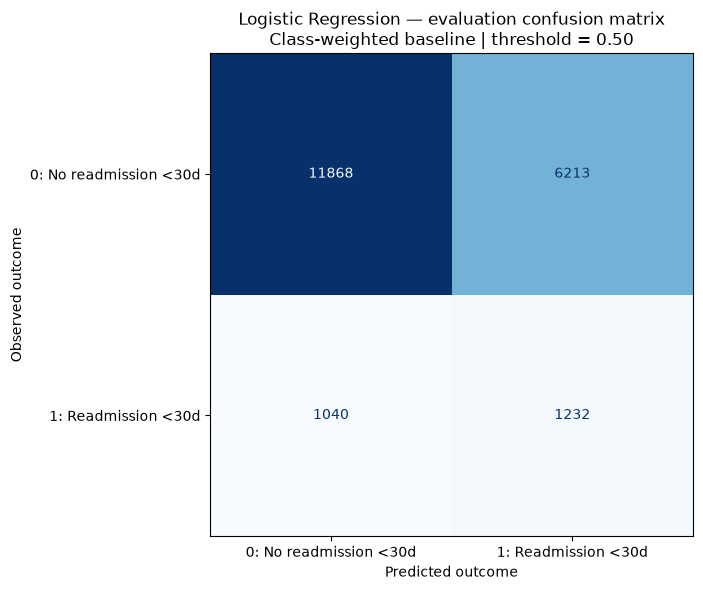

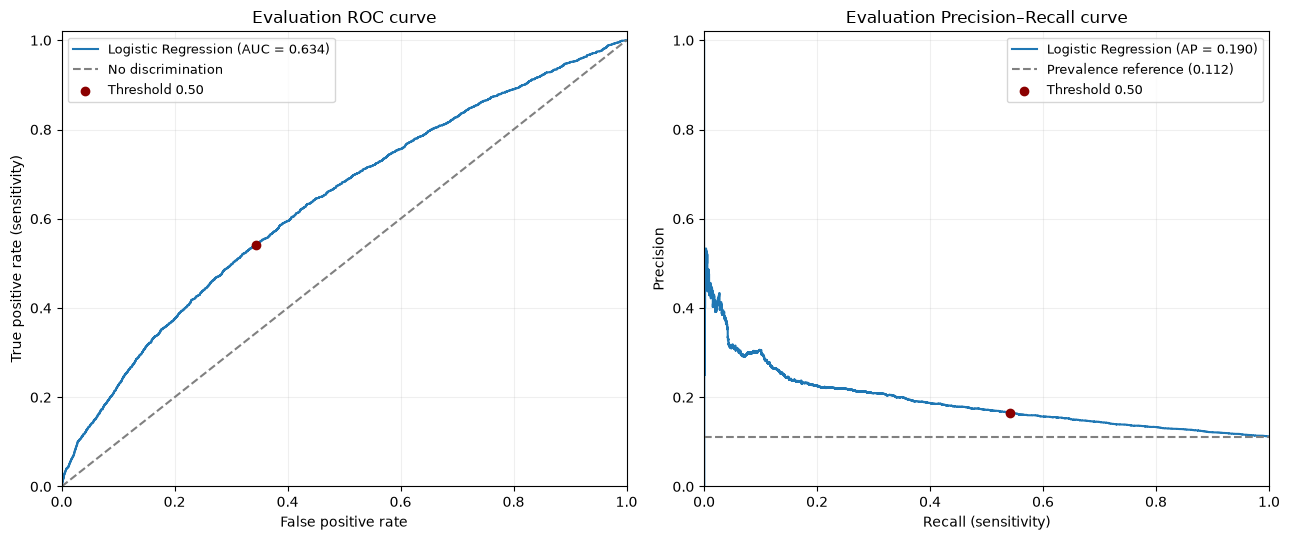

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ConfusionMatrixDisplay(
    confusion_matrix=logistic_confusion_matrix,
    display_labels=["0: No readmission <30d", "1: Readmission <30d"],
).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Logistic Regression — evaluation confusion matrix\nClass-weighted baseline | threshold = 0.50")
ax.set_xlabel("Predicted outcome")
ax.set_ylabel("Observed outcome")
fig.tight_layout()
display(fig)
plt.close(fig)

false_positive_rate, true_positive_rate, _ = roc_curve(y_evaluation, evaluation_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_evaluation, evaluation_probabilities)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].plot(false_positive_rate, true_positive_rate, label=f"Logistic Regression (AUC = {logistic_metrics['ROC_AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No discrimination")
axes[0].scatter([fp / (fp + tn)], [tp / (tp + fn)], color="darkred", zorder=3, label="Threshold 0.50")
axes[0].set(title="Evaluation ROC curve", xlabel="False positive rate", ylabel="True positive rate (sensitivity)")
axes[1].step(curve_recall, curve_precision, where="post", label=f"Logistic Regression (AP = {logistic_metrics['average_precision']:.3f})")
axes[1].axhline(y_evaluation.mean(), linestyle="--", color="gray", label=f"Prevalence reference ({y_evaluation.mean():.3f})")
axes[1].scatter([logistic_metrics["positive_recall"]], [logistic_metrics["positive_precision"]], color="darkred", zorder=3, label="Threshold 0.50")
axes[1].set(title="Evaluation Precision–Recall curve", xlabel="Recall (sensitivity)", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.2)
fig.tight_layout()
display(fig)
plt.close(fig)

## 16. Interpretation of the initial operating point

**Accuracy is not the primary metric:** the majority-class reference receives credit for the many negative encounters despite finding no positives. Positive-class recall, precision, F1, AP, and the error counts reveal behavior that accuracy hides. ROC-AUC complements these measures but does not express the burden of false alarms at a chosen threshold.

**Precision/recall trade-off:** increasing sensitivity generally requires flagging more encounters, which can add false positives and reduce precision. Class weighting emphasizes the minority class during training; the 0.50 threshold remains a provisional operating point, not an optimized or clinically validated cutoff.

**False negatives** are encounters followed by a recorded 30-day readmission that the model does not flag; in a potential follow-up workflow these could represent missed opportunities for review. **False positives** are flagged encounters without a recorded 30-day readmission and could add unnecessary follow-up workload. These interpretations do not imply that an intervention would prevent readmission, or that a negative label means no health risk. Class-weighted scores should not be presented as calibrated absolute risks without further validation.

In [14]:
print(f"At threshold {INITIAL_THRESHOLD:.2f}, Logistic Regression identifies {tp:,} of {tp + fn:,} positive encounters ({logistic_metrics['positive_recall']:.2%} recall).")
print(f"It misses {fn:,} positives and flags {fp:,} negative encounters; {tp + fp:,} encounters are flagged in total.")
print(f"Among flagged encounters, {logistic_metrics['positive_precision']:.2%} have a recorded 30-day readmission.")
print(f"Accuracy is {logistic_metrics['accuracy']:.2%}, compared with {majority_metrics['accuracy']:.2%} for always predicting zero.")
print(f"ROC-AUC: {logistic_metrics['ROC_AUC']:.4f}; average precision: {logistic_metrics['average_precision']:.4f}; prevalence reference: {y_evaluation.mean():.4f}.")

At threshold 0.50, Logistic Regression identifies 1,232 of 2,272 positive encounters (54.23% recall).
It misses 1,040 positives and flags 6,213 negative encounters; 7,445 encounters are flagged in total.
Among flagged encounters, 16.55% have a recorded 30-day readmission.
Accuracy is 64.36%, compared with 88.84% for always predicting zero.
ROC-AUC: 0.6339; average precision: 0.1897; prevalence reference: 0.1116.


## 17. Preliminary coefficient associations — not causation

Inspect the ten largest positive and ten most negative fitted coefficients, aligned with the existing transformed feature names. Positive coefficients increase the model's positive-class log-odds contribution; negative coefficients decrease it, conditional on other encoded predictors. Numeric coefficients correspond to a one-training-standard-deviation change after scaling. Categorical coefficients apply to indicator activation.

All category indicators are retained (`drop=None`), so individual categorical coefficients are not simple contrasts against an omitted reference category; contrasts between category coefficients are more meaningful. Correlated predictors, rare categories, L2 regularization, and class weighting affect these values. Large coefficients are not evidence of causal effects, stability, or clinical importance. This is a descriptive view of the fitted training model, not feature selection; no predictors are removed.

In [15]:
assert np.array_equal(logistic_regression.classes_, [0, 1])
assert logistic_regression.coef_.shape == (1, len(transformed_feature_names))
assert np.isfinite(logistic_regression.coef_).all()
coefficient_table = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "coefficient": logistic_regression.coef_[0],
})
coefficient_extremes = pd.concat([
    coefficient_table.query("coefficient > 0").nlargest(10, "coefficient").assign(direction="Largest positive"),
    coefficient_table.query("coefficient < 0").nsmallest(10, "coefficient").assign(direction="Most negative"),
], ignore_index=True)
with pd.option_context("display.max_rows", 20, "display.max_colwidth", 90):
    display(coefficient_extremes.round(4))

assert len(X_train) == 81_410 and len(X_evaluation) == 20_353
assert train_patient_ids.isdisjoint(evaluation_patient_ids)
assert model_training_index.equals(X_train.index)
assert model_training_index.intersection(y_evaluation.index).empty
assert fit_guard.fit_index_.equals(model_training_index)
assert state_hash(preprocessor) == preprocessing_state_before_model == fitted_state_before_evaluation
assert state_hash(logistic_regression) == model_state_before_prediction
assert len(selected_features) == 44
print("All baseline-evaluation assertions passed; patient split, predictors, preprocessing, and model state preserved.")

All baseline-evaluation assertions passed; patient split, predictors, preprocessing, and model state preserved.


,transformed_feature,coefficient,direction
0,categorical__diag_3_156,2.1763,Largest positive
1,categorical__diag_2_136,2.1194,Largest positive
2,categorical__diag_1_82,1.8470,Largest positive
3,categorical__diag_2_474,1.8101,Largest positive
4,categorical__diag_1_V58,1.7978,Largest positive
5,categorical__diag_2_V18,1.7541,Largest positive
6,categorical__diag_2_500,1.7310,Largest positive
7,categorical__diag_2_E950,1.7198,Largest positive
8,categorical__diag_3_602,1.7121,Largest positive
9,categorical__diag_1_146,1.6543,Largest positive


## 18. Logistic Regression baseline checkpoint

The training-derived majority-class reference and class-weighted Logistic Regression baseline have been evaluated at 0.50. The preceding tables and plots report classification metrics, confusion counts, probability ranking, and descriptive coefficient associations.

Validation checks cover prediction counts, probability bounds and normalization, class totals, training-only fitting, unchanged preprocessing, zero patient overlap, and all 44 predictors. The next sections add the prespecified Random Forest baseline; training-only, patient-grouped tuning follows in sections 25–31.

## 19. Random Forest: first nonlinear comparison

Fit one `RandomForestClassifier` with **200 trees, maximum depth 20, minimum leaf size 5, `max_features='sqrt'`, `class_weight='balanced'`, `random_state=42`, and `n_jobs=-1`**. These baseline settings are fixed in advance, not selected through a search: multiple trees reduce individual-tree variability, while depth and leaf-size limits constrain complexity in the sparse diagnosis feature space. Use the default Gini split criterion and bootstrap sampling within each tree. This standard forest bootstrap is not class-balancing oversampling or undersampling; no external resampling or SMOTE is applied. Balanced weights are derived only from training targets.

Reuse the same **81,410 training encounters**, **20,353 evaluation encounters**, 44 raw predictors, and 2,400 transformed columns. Tree splits do not require scaling, but using the already fitted preprocessing keeps the feature representation consistent; no scaler or encoder is refitted. Sparse matrices remain sparse. The original split and Logistic Regression code are unchanged.

The existing guarded training helper accepts only the designated training matrix and aligned training target. Snapshot the split, preprocessing, and Logistic Regression state before fitting, then verify that none changes. See [RandomForestClassifier documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf_split_snapshot = state_hash((train_positions, evaluation_positions, train_patient_groups, evaluation_patient_groups))
rf_preprocessing_snapshot = state_hash(preprocessor)
rf_logistic_snapshot = state_hash(logistic_regression)
rf_logistic_predictions_snapshot = evaluation_predictions.copy()
rf_logistic_probabilities_snapshot = evaluation_probabilities.copy()
rf_logistic_metrics_snapshot = logistic_metrics.copy()
rf_logistic_confusion_snapshot = logistic_confusion_matrix.copy()
rf_existing_comparison = pd.DataFrame([majority_metrics, logistic_metrics]).set_index("baseline")

random_forest_parameters = {
    "n_estimators": 200, "max_depth": 20, "min_samples_leaf": 5,
    "max_features": "sqrt", "criterion": "gini", "bootstrap": True,
    "class_weight": "balanced", "random_state": RANDOM_STATE, "n_jobs": -1,
}
display(pd.Series(random_forest_parameters, name="value").rename_axis("parameter").to_frame())
random_forest = RandomForestClassifier(**random_forest_parameters)
rf_training_index = fit_training_baseline(random_forest, X_train_transformed, y_train)
assert rf_training_index.equals(X_train.index) and rf_training_index.equals(fit_guard.fit_index_)
assert rf_training_index.intersection(X_evaluation.index).empty
assert set(patient_groups.loc[rf_training_index]).isdisjoint(evaluation_patient_ids)
assert random_forest.n_features_in_ == len(transformed_feature_names) == 2_400
assert len(random_forest.estimators_) == random_forest_parameters["n_estimators"]
assert state_hash(preprocessor) == rf_preprocessing_snapshot == fitted_state_before_evaluation
assert state_hash(logistic_regression) == rf_logistic_snapshot
print(f"Random Forest fitted on {len(rf_training_index):,} training encounters only.")

Random Forest fitted on 81,410 training encounters only.


,value
parameter,
n_estimators,200
max_depth,20
min_samples_leaf,5
max_features,sqrt
criterion,gini
bootstrap,True
class_weight,balanced
random_state,42
n_jobs,-1


## 20. Random Forest evaluation and three-baseline comparison

Use the same **untuned 0.50 threshold** and evaluation population as Logistic Regression. ROC-AUC and average precision use continuous positive-class probabilities; AP remains the PR summary rather than trapezoidal PR area. Report unweighted encounter-level metrics. Class weighting does not ensure probability calibration, and these scores should not be assumed to be calibrated absolute risks.

In [17]:
rf_state_before_prediction = state_hash(random_forest)
assert np.array_equal(random_forest.classes_, [0, 1])
rf_positive_position = int(np.flatnonzero(random_forest.classes_ == 1)[0])
rf_probability_matrix = random_forest.predict_proba(X_evaluation_transformed)
rf_evaluation_probabilities = rf_probability_matrix[:, rf_positive_position]
rf_evaluation_predictions = (rf_evaluation_probabilities >= INITIAL_THRESHOLD).astype(int)
assert INITIAL_THRESHOLD == 0.50
assert len(rf_evaluation_predictions) == len(rf_evaluation_probabilities) == len(y_evaluation) == 20_353
assert rf_probability_matrix.shape == (20_353, 2)
assert np.isfinite(rf_probability_matrix).all()
assert ((rf_probability_matrix >= 0) & (rf_probability_matrix <= 1)).all()
np.testing.assert_allclose(rf_probability_matrix.sum(axis=1), 1)
assert set(y_evaluation.unique()) == {0, 1}
assert set(np.unique(rf_evaluation_predictions)).issubset({0, 1})
assert state_hash(random_forest) == rf_state_before_prediction

rf_metrics = evaluation_metrics("Balanced Random Forest (0.50)", rf_evaluation_predictions, rf_evaluation_probabilities)
rf_confusion_matrix = confusion_matrix(y_evaluation, rf_evaluation_predictions, labels=[0, 1])
assert rf_confusion_matrix.shape == (2, 2) and rf_confusion_matrix.sum() == 20_353
np.testing.assert_array_equal(rf_confusion_matrix.sum(axis=1), y_evaluation.value_counts().reindex([0, 1]).to_numpy())
rf_tn, rf_fp, rf_fn, rf_tp = rf_confusion_matrix.ravel()
baseline_comparison = pd.DataFrame([majority_metrics, logistic_metrics, rf_metrics]).set_index("baseline")
pd.testing.assert_frame_equal(baseline_comparison.loc[rf_existing_comparison.index], rf_existing_comparison)
display(baseline_comparison.round(4))
confusion_count_summary = pd.DataFrame([
    {"baseline": name, "TN": int(matrix[0, 0]), "FP": int(matrix[0, 1]),
     "FN": int(matrix[1, 0]), "TP": int(matrix[1, 1])}
    for name, matrix in [("Majority class", majority_confusion_matrix),
                         ("Logistic Regression", logistic_confusion_matrix),
                         ("Random Forest", rf_confusion_matrix)]
])
display(confusion_count_summary)
print("Random Forest classification report — evaluation encounters, threshold 0.50:")
print(classification_report(
    y_evaluation, rf_evaluation_predictions, labels=[0, 1],
    target_names=["0: No 30-day readmission", "1: 30-day readmission"],
    digits=4, zero_division=0,
))

Random Forest classification report — evaluation encounters, threshold 0.50:
                          precision    recall  f1-score   support

0: No 30-day readmission     0.9216    0.6492    0.7618     18081
   1: 30-day readmission     0.1672    0.5603    0.2575      2272

                accuracy                         0.6393     20353
               macro avg     0.5444    0.6048    0.5097     20353
            weighted avg     0.8374    0.6393    0.7055     20353



,accuracy,positive_precision,positive_recall,positive_F1,ROC_AUC,average_precision
baseline,,,,,,
Majority class (always 0),0.8884,0.0000,0.0000,0.0000,0.5000,0.1116
Balanced Logistic Regression (0.50),0.6436,0.1655,0.5423,0.2536,0.6339,0.1897
Balanced Random Forest (0.50),0.6393,0.1672,0.5603,0.2575,0.6493,0.1880


,baseline,TN,FP,FN,TP
0,Majority class,18081,0,2272,0
1,Logistic Regression,11868,6213,1040,1232
2,Random Forest,11739,6342,999,1273


## 21. Random Forest confusion matrix and shared evaluation curves

Both ROC and Precision–Recall panels use the same evaluation outcomes. Circles mark the fixed 0.50 operating points; they do not represent optimized thresholds. Confusion-matrix rows are observed outcomes and columns are predictions.

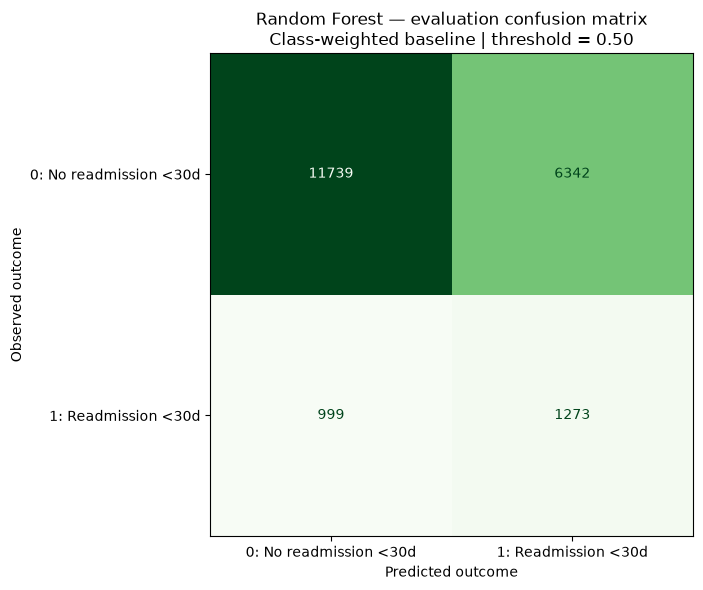

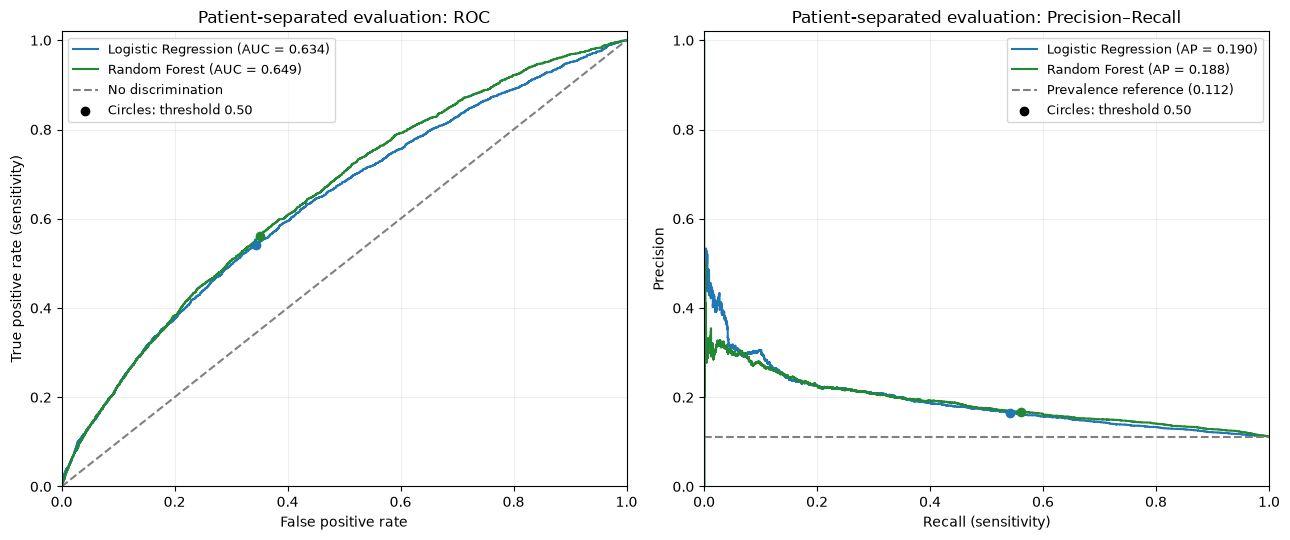

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 6))
ConfusionMatrixDisplay(
    confusion_matrix=rf_confusion_matrix,
    display_labels=["0: No readmission <30d", "1: Readmission <30d"],
).plot(ax=ax, cmap="Greens", values_format="d", colorbar=False)
ax.set(title="Random Forest — evaluation confusion matrix\nClass-weighted baseline | threshold = 0.50",
       xlabel="Predicted outcome", ylabel="Observed outcome")
fig.tight_layout()
display(fig)
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for name, probabilities, metrics, matrix, color in [
    ("Logistic Regression", evaluation_probabilities, logistic_metrics, logistic_confusion_matrix, "#1f77b4"),
    ("Random Forest", rf_evaluation_probabilities, rf_metrics, rf_confusion_matrix, "#228833"),
]:
    fpr_values, tpr_values, _ = roc_curve(y_evaluation, probabilities)
    precision_values, recall_values, _ = precision_recall_curve(y_evaluation, probabilities)
    axes[0].plot(fpr_values, tpr_values, color=color, label=f"{name} (AUC = {metrics['ROC_AUC']:.3f})")
    axes[1].step(recall_values, precision_values, where="post", color=color, label=f"{name} (AP = {metrics['average_precision']:.3f})")
    axes[0].scatter([matrix[0, 1] / matrix[0].sum()], [metrics["positive_recall"]], color=color, zorder=3)
    axes[1].scatter([metrics["positive_recall"]], [metrics["positive_precision"]], color=color, zorder=3)
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="No discrimination")
axes[1].axhline(y_evaluation.mean(), linestyle="--", color="gray", label=f"Prevalence reference ({y_evaluation.mean():.3f})")
axes[0].set(title="Patient-separated evaluation: ROC", xlabel="False positive rate", ylabel="True positive rate (sensitivity)")
axes[1].set(title="Patient-separated evaluation: Precision–Recall", xlabel="Recall (sensitivity)", ylabel="Precision")
for ax in axes:
    ax.scatter([], [], color="black", label="Circles: threshold 0.50")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.2)
fig.tight_layout()
display(fig)
plt.close(fig)

## 22. Training-derived transformed feature importance

Map `feature_importances_` to the existing transformed feature names and show the top 15. These normalized, impurity-based importances describe the contribution to weighted impurity reductions within the fitted training forest. They do not show effect direction, causal effects, or guaranteed performance on new patients.

Impurity importance can favor variables with many possible splits; correlated features can share importance, and one-hot encoding distributes a raw categorical predictor across many indicators. Interpret this transformed-feature ranking as preliminary model description, not feature selection. No evaluation-target information is used to compute these importances and no predictors are removed.

,transformed_feature,importance
0,numeric__number_inpatient,0.18815
1,numeric__time_in_hospital,0.04175
2,numeric__number_emergency,0.04162
3,numeric__number_diagnoses,0.03502
4,numeric__num_medications,0.03347
5,numeric__num_lab_procedures,0.02216
6,numeric__number_outpatient,0.01419
7,categorical__diag_1_V58,0.01327
8,categorical__diag_3_401,0.01201
9,numeric__num_procedures,0.01190


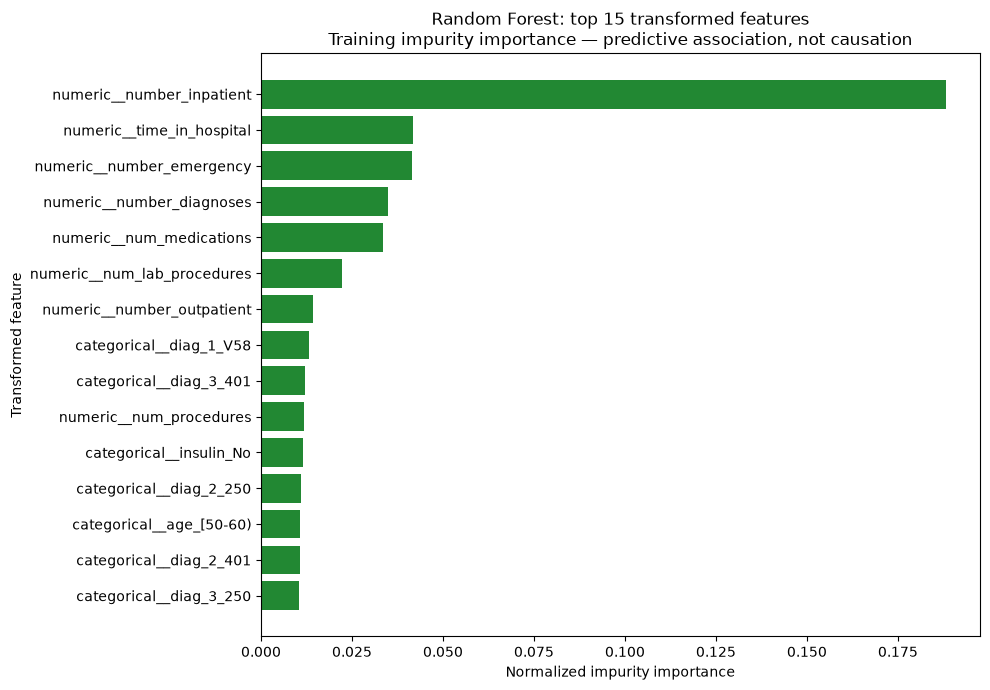

In [19]:
rf_feature_importance = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "importance": random_forest.feature_importances_,
}).sort_values("importance", ascending=False, kind="stable").reset_index(drop=True)
assert len(rf_feature_importance) == len(transformed_feature_names)
assert rf_feature_importance["transformed_feature"].is_unique
assert np.isfinite(rf_feature_importance["importance"]).all()
assert rf_feature_importance["importance"].ge(0).all()
np.testing.assert_allclose(rf_feature_importance["importance"].sum(), 1.0)
rf_top_features = rf_feature_importance.head(15).copy()
with pd.option_context("display.max_colwidth", 90):
    display(rf_top_features.round(5))
fig, ax = plt.subplots(figsize=(10, 7))
ordered_importance = rf_top_features.iloc[::-1]
ax.barh(ordered_importance["transformed_feature"], ordered_importance["importance"], color="#228833")
ax.set(title="Random Forest: top 15 transformed features\nTraining impurity importance — predictive association, not causation",
       xlabel="Normalized impurity importance", ylabel="Transformed feature")
fig.tight_layout()
display(fig)
plt.close(fig)

## 23. Descriptive comparison and validation

The table below reports Random Forest minus Logistic Regression for each metric; the printed error counts show the associated false-alarm and missed-readmission burden. Higher recall means fewer false negatives, while higher precision means a greater fraction of flagged encounters are positive. F1 summarizes the precision/recall balance at 0.50; ROC-AUC and AP describe ranking across thresholds. Accuracy remains secondary because the majority-class reference detects no positives.

These are two fixed baseline configurations on one patient-separated evaluation set. No final winner is declared, no threshold or hyperparameter is selected from these results, and no additional model is introduced. Any later development must use training-only, patient-grouped validation; repeated use of this evaluation set for decisions would weaken its held-out role.

In [20]:
rf_vs_logistic = pd.DataFrame([
    {"metric": metric, "Logistic Regression": logistic_metrics[metric],
     "Random Forest": rf_metrics[metric], "RF minus LR": rf_metrics[metric] - logistic_metrics[metric]}
    for metric in ["accuracy", "positive_precision", "positive_recall", "positive_F1", "ROC_AUC", "average_precision"]
])
display(rf_vs_logistic.round(4))
for metric, label in [("positive_recall", "Recall"), ("positive_precision", "Precision"),
                      ("positive_F1", "F1"), ("ROC_AUC", "ROC-AUC"), ("average_precision", "Average precision")]:
    delta = rf_metrics[metric] - logistic_metrics[metric]
    direction = "higher" if delta > 0 else "lower" if delta < 0 else "unchanged"
    print(f"{label}: RF {rf_metrics[metric]:.4f} versus LR {logistic_metrics[metric]:.4f} ({direction}).")
print(f"False positives: RF {rf_fp:,} versus LR {fp:,} ({rf_fp - fp:+,}); these are flagged encounters without recorded 30-day readmission.")
print(f"False negatives: RF {rf_fn:,} versus LR {fn:,} ({rf_fn - fn:+,}); these are recorded readmissions the model misses.")
print("Top transformed features: " + ", ".join(rf_top_features["transformed_feature"].head(5)))

assert state_hash((train_positions, evaluation_positions, train_patient_groups, evaluation_patient_groups)) == rf_split_snapshot
assert len(X_train) == 81_410 and len(X_evaluation) == 20_353
assert train_patient_ids.isdisjoint(evaluation_patient_ids)
assert len(selected_features) == 44 and not set(selected_features).intersection(exclusion_reasons)
assert rf_training_index.equals(model_training_index) and rf_training_index.equals(fit_guard.fit_index_)
assert rf_training_index.intersection(X_evaluation.index).empty
assert state_hash(preprocessor) == rf_preprocessing_snapshot == fitted_state_before_evaluation
assert state_hash(logistic_regression) == rf_logistic_snapshot == model_state_before_prediction
np.testing.assert_array_equal(evaluation_predictions, rf_logistic_predictions_snapshot)
np.testing.assert_array_equal(evaluation_probabilities, rf_logistic_probabilities_snapshot)
np.testing.assert_array_equal(logistic_confusion_matrix, rf_logistic_confusion_snapshot)
assert logistic_metrics == rf_logistic_metrics_snapshot
np.testing.assert_allclose(
    logistic_regression.predict_proba(X_evaluation_transformed)[:, positive_class_position],
    rf_logistic_probabilities_snapshot, rtol=0, atol=0,
)
assert state_hash(random_forest) == rf_state_before_prediction
print("All Random Forest checks passed: training-only fitting, 20,353 valid predictions, probability bounds, confusion totals, zero patient overlap, unchanged split/preprocessing and Logistic Regression results.")

Recall: RF 0.5603 versus LR 0.5423 (higher).
Precision: RF 0.1672 versus LR 0.1655 (higher).
F1: RF 0.2575 versus LR 0.2536 (higher).
ROC-AUC: RF 0.6493 versus LR 0.6339 (higher).
Average precision: RF 0.1880 versus LR 0.1897 (lower).
False positives: RF 6,342 versus LR 6,213 (+129); these are flagged encounters without recorded 30-day readmission.
False negatives: RF 999 versus LR 1,040 (-41); these are recorded readmissions the model misses.
Top transformed features: numeric__number_inpatient, numeric__time_in_hospital, numeric__number_emergency, numeric__number_diagnoses, numeric__num_medications
All Random Forest checks passed: training-only fitting, 20,353 valid predictions, probability bounds, confusion totals, zero patient overlap, unchanged split/preprocessing and Logistic Regression results.


,metric,Logistic Regression,Random Forest,RF minus LR
0,accuracy,0.6436,0.6393,-0.0043
1,positive_precision,0.1655,0.1672,0.0017
2,positive_recall,0.5423,0.5603,0.0180
3,positive_F1,0.2536,0.2575,0.0039
4,ROC_AUC,0.6339,0.6493,0.0154
5,average_precision,0.1897,0.1880,-0.0017


## 24. Baseline comparison checkpoint

The majority-class reference, class-weighted Logistic Regression, and class-weighted Random Forest have been evaluated on the same patient-separated partition. The tables, confusion matrices, ROC and precision–recall plots, and descriptive feature summaries retain the fixed 0.50 operating point. Neither baseline comparison selects a final model or threshold.

The split and fitted preprocessing remain unchanged. The following tuning stage uses raw training predictors with fresh preprocessing inside each patient-separated CV fold.

## 25. Controlled tuning protocol: training data only

Keep the existing patient-separated partition exactly as defined: **81,410 training encounters and 20,353 evaluation encounters**. All new CV folds are drawn only from `X_train`, `y_train`, and `train_patient_groups`. The existing evaluation results have already been reported in prior sections; this is not a previously unseen test set, but it remains excluded from this search and is not consulted again until both configurations are finalized.

Use **3-fold StratifiedGroupKFold, shuffle=True, random_state=42**, with identical folds for both searches. Patient separation takes priority over exact class balance. Optimize **mean average precision (AP)**, collecting ROC-AUC as a secondary descriptive score. Accuracy would reward the majority class while overlooking missed positives. AP emphasizes positive-class retrieval and does not choose a classification threshold. Fold standard deviations describe variability, not confidence intervals.

The search is deliberately small: **6 Logistic Regression configurations** (`C` = 0.1, 1, 10 × `class_weight` = balanced, None), with fixed compatible default L2 / liblinear settings; **4 prespecified Random Forest configurations** vary depth, minimum leaf size, and feature subsampling while keeping 200 trees and balanced weights. These are a bounded set, not a full forest Cartesian grid. The baseline configurations are included. No choices are changed after viewing CV or evaluation results.

Use one search worker and two forest workers to limit memory and avoid nested CPU oversubscription on a local MacBook. There are 30 CV fits and two final training refits. Both searches use `refit=False`; only after both parameter selections are frozen are complete pipelines refitted on all training data. See [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) and [StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html).

In [21]:
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, ParameterGrid

# Integrity snapshots only; no evaluation outcomes or scores enter the search.
tuning_split_snapshot = state_hash((train_positions, evaluation_positions, train_patient_groups, evaluation_patient_groups))
tuning_evaluation_snapshot = state_hash((X_evaluation, y_evaluation))
tuning_baseline_snapshot = state_hash((preprocessor, logistic_regression, random_forest, logistic_metrics, rf_metrics))
assert X_train.index.equals(y_train.index) and X_train.index.equals(train_patient_groups.index)
assert X_train.columns.tolist() == selected_features and X_train.shape == (81_410, 44)
assert train_patient_ids.isdisjoint(evaluation_patient_ids)

training_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
training_cv_splits = list(training_cv.split(X_train, y_train, groups=train_patient_groups))
cv_fold_rows = []
validation_coverage = np.zeros(len(X_train), dtype=int)
for fold, (fit_positions, validation_positions) in enumerate(training_cv_splits, start=1):
    fit_groups = set(train_patient_groups.iloc[fit_positions])
    validation_groups = set(train_patient_groups.iloc[validation_positions])
    assert fit_groups.isdisjoint(validation_groups)
    assert (fit_groups | validation_groups).isdisjoint(evaluation_patient_ids)
    assert not set(fit_positions).intersection(validation_positions)
    assert np.array_equal(np.sort(np.r_[fit_positions, validation_positions]), np.arange(len(X_train)))
    assert set(y_train.iloc[fit_positions]) == set(y_train.iloc[validation_positions]) == {0, 1}
    validation_coverage[validation_positions] += 1
    cv_fold_rows.append({
        "fold": fold, "fit_encounters": len(fit_positions), "validation_encounters": len(validation_positions),
        "fit_patients": len(fit_groups), "validation_patients": len(validation_groups),
        "patient_overlap": len(fit_groups & validation_groups),
        "fit_prevalence_pct": y_train.iloc[fit_positions].mean() * 100,
        "validation_prevalence_pct": y_train.iloc[validation_positions].mean() * 100,
    })
assert (validation_coverage == 1).all()
display(pd.DataFrame(cv_fold_rows).round(4))

lr_parameter_grid = {"model__C": [0.1, 1.0, 10.0], "model__class_weight": ["balanced", None]}
rf_parameter_grid = [
    {"model__n_estimators": [200], "model__max_depth": [20], "model__min_samples_leaf": [5], "model__max_features": ["sqrt"]},
    {"model__n_estimators": [200], "model__max_depth": [None], "model__min_samples_leaf": [5], "model__max_features": ["sqrt"]},
    {"model__n_estimators": [200], "model__max_depth": [20], "model__min_samples_leaf": [10], "model__max_features": ["sqrt"]},
    {"model__n_estimators": [200], "model__max_depth": [20], "model__min_samples_leaf": [10], "model__max_features": [0.1]},
]
for name, grid in [("Logistic Regression", lr_parameter_grid), ("Random Forest", rf_parameter_grid)]:
    print(f"{name}: {len(ParameterGrid(grid))} configurations × 3 folds")
    display(pd.DataFrame(list(ParameterGrid(grid))))

Logistic Regression: 6 configurations × 3 folds
Random Forest: 4 configurations × 3 folds


,fold,fit_encounters,validation_encounters,fit_patients,validation_patients,patient_overlap,fit_prevalence_pct,validation_prevalence_pct
0,1,54272,27138,38186,18989,0,11.1586,11.1615
1,2,54274,27136,38095,19080,0,11.1600,11.1586
2,3,54274,27136,38069,19106,0,11.1600,11.1586


,model__C,model__class_weight
0,0.1,balanced
1,0.1,NaN
2,1.0,balanced
3,1.0,NaN
4,10.0,balanced
5,10.0,NaN


,model__max_depth,model__max_features,model__min_samples_leaf,model__n_estimators
0,20.0,sqrt,5,200
1,NaN,sqrt,5,200
2,20.0,sqrt,10,200
3,20.0,0.1,10,200


## 26. Fold-local preprocessing and fit audit

The earlier `TrainingPartitionGuard` requires the complete training index, so it cannot be reused unchanged for CV subsets. A separate CV guard admits only the prevalidated fold-training index signatures, while a separate final-refit guard admits only the complete training index. The original pipeline is unchanged.

Every candidate is a **Pipeline(guard → fresh cloned ColumnTransformer → model)** receiving the 44 raw columns. Cloning discards fitted medians, scales, and category vocabularies. Each fold therefore learns preprocessing solely within that fold's training rows; the previously transformed full-training matrix is never passed to the search. The scorer checks the fitted row indices against validation patients and verifies learned preprocessing against the actual fold-training data before scoring.

The audit log is local to this serial search (`n_jobs=1`). It records each fit boundary; it is not a substitute for the pipeline isolation itself. No caching across folds is used.

In [22]:
CV_FIT_AUDIT = []
fold_fit_signatures = tuple(state_hash(X_train.index[positions]) for positions, _ in training_cv_splits)
full_training_signature = state_hash(X_train.index)

class CVTrainingGuard(TransformerMixin, BaseEstimator):
    def __init__(self, allowed_signatures):
        self.allowed_signatures = allowed_signatures

    def fit(self, features, target=None):
        signature = state_hash(features.index)
        assert signature in self.allowed_signatures, "Unapproved fitting rows."
        assert features.columns.tolist() == selected_features
        pd.testing.assert_frame_equal(features, X_train.loc[features.index])
        pd.testing.assert_series_equal(target, y_train.loc[features.index])
        self.fit_index_ = features.index.copy()
        self.feature_names_in_ = np.asarray(features.columns, dtype=object)
        self.n_features_in_ = features.shape[1]
        CV_FIT_AUDIT.append({"fit_signature": signature, "fit_rows": len(features)})
        return self

    def transform(self, features):
        assert np.array_equal(features.columns, self.feature_names_in_)
        return features

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_in_.copy()

def make_tuning_pipeline(model, allowed_signatures):
    fresh_columns = clone(column_preprocessor)
    assert isinstance(fresh_columns, ColumnTransformer) and not hasattr(fresh_columns, "transformers_")
    return Pipeline([
        ("fit_guard", CVTrainingGuard(allowed_signatures)),
        ("preprocessing", fresh_columns),
        ("model", model),
    ])

def audit_learned_preprocessing(estimator):
    fit_index = estimator.named_steps["fit_guard"].fit_index_
    fit_raw = X_train.loc[fit_index]
    columns = estimator.named_steps["preprocessing"]
    assert isinstance(columns, ColumnTransformer)
    assert np.array_equal(columns.feature_names_in_, selected_features)
    numeric = columns.named_transformers_["numeric"]
    np.testing.assert_allclose(numeric.named_steps["imputer"].statistics_, fit_raw[numeric_features].median())
    imputed = numeric.named_steps["imputer"].transform(fit_raw[numeric_features])
    scaler_here = numeric.named_steps["scaler"]
    assert np.all(np.asarray(scaler_here.n_samples_seen_) == len(fit_raw))
    np.testing.assert_allclose(scaler_here.mean_, imputed.mean(axis=0))
    np.testing.assert_allclose(scaler_here.var_, imputed.var(axis=0))
    categorical = columns.named_transformers_["categorical"]
    expected_categories = normalize_categorical_missingness(fit_raw[categorical_features]).fillna(MISSING_CATEGORY)
    for column, categories in zip(categorical_features, categorical.named_steps["encoder"].categories_):
        assert set(categories) == set(expected_categories[column])
    return fit_index

def training_cv_scores(estimator, validation_features, validation_target):
    fit_index = audit_learned_preprocessing(estimator)
    assert fit_index.intersection(validation_features.index).empty
    assert set(train_patient_groups.loc[fit_index]).isdisjoint(train_patient_groups.loc[validation_features.index])
    pd.testing.assert_series_equal(validation_target, y_train.loc[validation_features.index])
    probability = estimator.predict_proba(validation_features)[:, 1]
    assert np.isfinite(probability).all() and ((probability >= 0) & (probability <= 1)).all()
    return {"average_precision": average_precision_score(validation_target, probability),
            "roc_auc": roc_auc_score(validation_target, probability)}

lr_search_pipeline = make_tuning_pipeline(
    LogisticRegression(solver="liblinear", max_iter=2000, random_state=RANDOM_STATE), fold_fit_signatures,
)
rf_search_pipeline = make_tuning_pipeline(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=2), fold_fit_signatures,
)
for pipeline in [lr_search_pipeline, rf_search_pipeline]:
    assert isinstance(pipeline, Pipeline)
    assert isinstance(pipeline.named_steps["preprocessing"], ColumnTransformer)
    assert not hasattr(pipeline.named_steps["preprocessing"], "transformers_")

## 27. Run the limited searches and freeze selections

Pass only raw training predictors and their aligned targets to `GridSearchCV`; the supplied split indices were constructed with training patient groups and explicitly validated above. AP is the only selection criterion. Exact mean-AP ties use the first prespecified configuration. ROC-AUC and fold variability are reported without altering selection. `error_score='raise'` and convergence warnings treated as errors prevent silently accepting failed fits.

In [23]:
tuning_searches = {}
cv_results_tables = {}
selected_parameters = {}
cv_best_rows = []
for name, pipeline, grid in [
    ("Logistic Regression", lr_search_pipeline, lr_parameter_grid),
    ("Random Forest", rf_search_pipeline, rf_parameter_grid),
]:
    print(f"Starting {name}: {len(ParameterGrid(grid)) * 3} CV fits on raw training data only.", flush=True)
    search = GridSearchCV(
        estimator=pipeline, param_grid=grid, scoring=training_cv_scores,
        cv=training_cv_splits, refit=False, n_jobs=1, pre_dispatch=1,
        error_score="raise", return_train_score=False,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        search.fit(X_train, y_train)
    results = pd.DataFrame(search.cv_results_)
    assert len(results) == len(ParameterGrid(grid))
    assert np.isfinite(results[["mean_test_average_precision", "std_test_average_precision", "mean_test_roc_auc", "std_test_roc_auc"]].to_numpy()).all()
    best_position = int(np.argmax(results["mean_test_average_precision"].to_numpy()))
    selected_parameters[name] = dict(results.iloc[best_position]["params"])
    tuning_searches[name] = search
    report_columns = ["params", "mean_test_average_precision", "std_test_average_precision", "mean_test_roc_auc", "std_test_roc_auc"]
    report_columns += [f"split{fold}_test_average_precision" for fold in range(3)]
    cv_results_tables[name] = results[report_columns].copy()
    print(name + " — every evaluated configuration:")
    with pd.option_context("display.max_colwidth", None, "display.max_columns", None):
        display(cv_results_tables[name].round(5))
    best = results.iloc[best_position]
    cv_best_rows.append({"model": name, "configurations": len(results), "best_parameters": selected_parameters[name],
                         "mean_CV_AP": best["mean_test_average_precision"], "std_CV_AP": best["std_test_average_precision"],
                         "mean_CV_ROC_AUC": best["mean_test_roc_auc"], "std_CV_ROC_AUC": best["std_test_roc_auc"]})

expected_cv_fits = 3 * (len(ParameterGrid(lr_parameter_grid)) + len(ParameterGrid(rf_parameter_grid)))
assert len(CV_FIT_AUDIT) == expected_cv_fits == 30
for signature in fold_fit_signatures:
    assert sum(row["fit_signature"] == signature for row in CV_FIT_AUDIT) == 10
assert full_training_signature not in [row["fit_signature"] for row in CV_FIT_AUDIT]
cv_best_summary = pd.DataFrame(cv_best_rows)
with pd.option_context("display.max_colwidth", None):
    display(cv_best_summary.round(5))
selection_fingerprint = state_hash(selected_parameters)
selections_finalized = True
assert state_hash((X_evaluation, y_evaluation)) == tuning_evaluation_snapshot
print("Both parameter selections finalized using training-CV average precision only.")

Starting Logistic Regression: 18 CV fits on raw training data only.
Logistic Regression — every evaluated configuration:
Starting Random Forest: 12 CV fits on raw training data only.
Random Forest — every evaluated configuration:
Both parameter selections finalized using training-CV average precision only.


,params,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,std_test_roc_auc,split0_test_average_precision,split1_test_average_precision,split2_test_average_precision
0,"{'model__C': 0.1, 'model__class_weight': 'balanced'}",0.19480,0.00217,0.63632,0.00143,0.19272,0.19390,0.19779
1,"{'model__C': 0.1, 'model__class_weight': None}",0.19745,0.00168,0.63990,0.00301,0.19564,0.19702,0.19969
2,"{'model__C': 1.0, 'model__class_weight': 'balanced'}",0.18637,0.00260,0.62178,0.00156,0.18306,0.18665,0.18941
3,"{'model__C': 1.0, 'model__class_weight': None}",0.18773,0.00227,0.62515,0.00245,0.18466,0.18842,0.19009
4,"{'model__C': 10.0, 'model__class_weight': 'balanced'}",0.17848,0.00386,0.61467,0.00187,0.17310,0.18038,0.18196
5,"{'model__C': 10.0, 'model__class_weight': None}",0.17757,0.00428,0.61489,0.00299,0.17154,0.18013,0.18105


,params,mean_test_average_precision,std_test_average_precision,mean_test_roc_auc,std_test_roc_auc,split0_test_average_precision,split1_test_average_precision,split2_test_average_precision
0,"{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 200}",0.18907,0.00408,0.64189,0.00238,0.18730,0.18520,0.19470
1,"{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 200}",0.19065,0.00381,0.64486,0.00245,0.18761,0.18832,0.19603
2,"{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 200}",0.18754,0.00340,0.64076,0.00303,0.18462,0.18569,0.19231
3,"{'model__max_depth': 20, 'model__max_features': 0.1, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}",0.19610,0.00343,0.64512,0.00193,0.19362,0.19372,0.20095


,model,configurations,best_parameters,mean_CV_AP,std_CV_AP,mean_CV_ROC_AUC,std_CV_ROC_AUC
0,Logistic Regression,6,"{'model__C': 0.1, 'model__class_weight': None}",0.19745,0.00168,0.63990,0.00301
1,Random Forest,4,"{'model__max_depth': 20, 'model__max_features': 0.1, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}",0.19610,0.00343,0.64512,0.00193


## 28. Refit the finalized complete pipelines on full training data

Now clone each unfitted search template, install its frozen parameters, admit only the full training index, and fit once on the entire training partition. Each final pipeline includes newly fitted preprocessing. This is separate from—and does not mutate—the original baseline preprocessing or models. No evaluation prediction is made until both final refits and fit-provenance checks finish.

In [24]:
assert selections_finalized and state_hash(selected_parameters) == selection_fingerprint
tuned_pipelines = {}
for name, template in [("Logistic Regression", lr_search_pipeline), ("Random Forest", rf_search_pipeline)]:
    finalized = clone(template).set_params(**selected_parameters[name])
    finalized.set_params(fit_guard__allowed_signatures=(full_training_signature,))
    with warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        finalized.fit(X_train, y_train)
    assert audit_learned_preprocessing(finalized).equals(X_train.index)
    assert finalized.named_steps["fit_guard"].fit_index_.intersection(X_evaluation.index).empty
    feature_names = finalized.named_steps["preprocessing"].get_feature_names_out()
    assert finalized.named_steps["model"].n_features_in_ == len(feature_names)
    assert np.array_equal(finalized.named_steps["model"].classes_, [0, 1])
    tuned_pipelines[name] = finalized
assert len(CV_FIT_AUDIT) == expected_cv_fits + 2
assert all(row["fit_signature"] == full_training_signature for row in CV_FIT_AUDIT[-2:])
assert len(tuned_pipelines) == 2
assert state_hash((preprocessor, logistic_regression, random_forest, logistic_metrics, rf_metrics)) == tuning_baseline_snapshot
print("Both selected complete pipelines refitted on 81,410 training encounters; ready for final evaluation.")

Both selected complete pipelines refitted on 81,410 training encounters; ready for final evaluation.


## 29. One evaluation per finalized tuned pipeline

Only now generate one probability matrix for each finalized pipeline on the existing evaluation rows. Cache those probabilities for all metrics; do not refit, reconsider parameters, or repeat predictions to choose a result. Keep the **0.50 threshold** for both models. No threshold optimization, calibration fit, resampling, or feature selection is performed.

The five-row comparison distinguishes earlier baselines from the tuned configurations. AP-based tuning targets ranking, so it need not improve recall or F1 at 0.50, particularly when class weighting changes. An unchanged configuration is a valid outcome of a limited search.

In [25]:
assert selections_finalized and state_hash(selected_parameters) == selection_fingerprint
assert state_hash((X_evaluation, y_evaluation)) == tuning_evaluation_snapshot
assert train_patient_ids.isdisjoint(evaluation_patient_ids)
tuned_predictions = {}
tuned_metrics = {}
tuned_confusion_matrices = {}
final_evaluation_call_counts = {name: 0 for name in tuned_pipelines}
for name, pipeline in tuned_pipelines.items():
    state_before = state_hash(pipeline)
    probability_matrix = pipeline.predict_proba(X_evaluation)
    final_evaluation_call_counts[name] += 1
    assert probability_matrix.shape == (20_353, 2)
    assert np.isfinite(probability_matrix).all()
    assert ((probability_matrix >= 0) & (probability_matrix <= 1)).all()
    np.testing.assert_allclose(probability_matrix.sum(axis=1), 1)
    probabilities = probability_matrix[:, 1]
    predictions = (probabilities >= INITIAL_THRESHOLD).astype(int)
    assert INITIAL_THRESHOLD == 0.50 and len(predictions) == len(y_evaluation) == 20_353
    assert set(y_evaluation.unique()) == {0, 1}
    tuned_predictions[name] = {"probabilities": probabilities, "predictions": predictions}
    tuned_metrics[name] = evaluation_metrics(f"Tuned {name} (0.50)", predictions, probabilities)
    matrix = confusion_matrix(y_evaluation, predictions, labels=[0, 1])
    assert matrix.sum() == 20_353
    np.testing.assert_array_equal(matrix.sum(axis=1), y_evaluation.value_counts().reindex([0, 1]).to_numpy())
    tuned_confusion_matrices[name] = matrix
    assert state_hash(pipeline) == state_before
assert all(count == 1 for count in final_evaluation_call_counts.values())

baseline_comparison = pd.DataFrame([
    {**majority_metrics, "baseline": "Majority baseline"},
    {**logistic_metrics, "baseline": "Baseline Logistic Regression"},
    {**rf_metrics, "baseline": "Baseline Random Forest"},
    tuned_metrics["Logistic Regression"], tuned_metrics["Random Forest"],
]).set_index("baseline")
display(baseline_comparison.round(5))
tuned_confusion_summary = pd.DataFrame([
    {"model": name, "TN": int(matrix[0, 0]), "FP": int(matrix[0, 1]),
     "FN": int(matrix[1, 0]), "TP": int(matrix[1, 1])}
    for name, matrix in tuned_confusion_matrices.items()
])
display(tuned_confusion_summary)

baseline_tuned_differences = pd.DataFrame([
    {"model": name, "metric": metric, "baseline": original[metric], "tuned": tuned_metrics[name][metric],
     "tuned_minus_baseline": tuned_metrics[name][metric] - original[metric]}
    for name, original in [("Logistic Regression", logistic_metrics), ("Random Forest", rf_metrics)]
    for metric in ["accuracy", "positive_precision", "positive_recall", "positive_F1", "ROC_AUC", "average_precision"]
])
display(baseline_tuned_differences.round(5))
for name, original in [("Logistic Regression", logistic_confusion_matrix), ("Random Forest", rf_confusion_matrix)]:
    matrix = tuned_confusion_matrices[name]
    print(f"{name}: false positives {matrix[0, 1]:,} ({matrix[0, 1] - original[0, 1]:+,} vs baseline); false negatives {matrix[1, 0]:,} ({matrix[1, 0] - original[1, 0]:+,} vs baseline).")

Logistic Regression: false positives 39 (-6,174 vs baseline); false negatives 2,241 (+1,201 vs baseline).
Random Forest: false positives 4,995 (-1,347 vs baseline); false negatives 1,182 (+183 vs baseline).


,accuracy,positive_precision,positive_recall,positive_F1,ROC_AUC,average_precision
baseline,,,,,,
Majority baseline,0.88837,0.00000,0.00000,0.00000,0.50000,0.11163
Baseline Logistic Regression,0.64364,0.16548,0.54225,0.25358,0.63393,0.18967
Baseline Random Forest,0.63932,0.16717,0.56030,0.25751,0.64935,0.18797
Tuned Logistic Regression (0.50),0.88798,0.44286,0.01364,0.02647,0.64780,0.19863
Tuned Random Forest (0.50),0.69651,0.17913,0.47975,0.26086,0.65140,0.19931


,model,TN,FP,FN,TP
0,Logistic Regression,18042,39,2241,31
1,Random Forest,13086,4995,1182,1090


,model,metric,baseline,tuned,tuned_minus_baseline
0,Logistic Regression,accuracy,0.64364,0.88798,0.24434
1,Logistic Regression,positive_precision,0.16548,0.44286,0.27738
2,Logistic Regression,positive_recall,0.54225,0.01364,-0.52861
3,Logistic Regression,positive_F1,0.25358,0.02647,-0.22710
4,Logistic Regression,ROC_AUC,0.63393,0.64780,0.01386
5,Logistic Regression,average_precision,0.18967,0.19863,0.00896
6,Random Forest,accuracy,0.63932,0.69651,0.05719
7,Random Forest,positive_precision,0.16717,0.17913,0.01196
8,Random Forest,positive_recall,0.56030,0.47975,-0.08055
9,Random Forest,positive_F1,0.25751,0.26086,0.00335


## 30. Interpretation and leakage checks

In this run, training CV selected **Logistic Regression with C=0.1 and no class weighting** (mean CV AP 0.19745 ± 0.00168). Evaluation AP rose from 0.18967 to 0.19863 and ROC-AUC from 0.63393 to 0.64780. At 0.50, precision increased from 16.55% to 44.29%, but recall fell from 54.23% to 1.36% and F1 from 0.25358 to 0.02647. It flagged just 70 encounters and detected only 31 of 2,272 positives. The higher accuracy does not make this operating point useful for identifying most readmissions.

Training CV selected **Random Forest with 200 trees, depth 20, minimum leaf size 10, max_features=0.1, and balanced class weights** (mean CV AP 0.19610 ± 0.00343). Evaluation AP increased from 0.18797 to 0.19931 and ROC-AUC from 0.64935 to 0.65140. Precision rose from 16.72% to 17.91%, recall fell from 56.03% to 47.98%, and F1 rose slightly from 0.25751 to 0.26086. False positives decreased by 1,347 while false negatives increased by 183. These trade-offs do not establish a final model choice.

Read baseline-to-tuned differences across recall, precision, F1, ROC-AUC, AP, and error counts together. A higher CV AP does not guarantee higher evaluation AP: folds and the held-out population differ, and selecting the best of several configurations introduces selection variability. A lower false-positive count can accompany more missed readmissions; improved ranking need not improve the fixed-threshold operating point. Class-weighted probabilities remain uncalibrated unless separately validated.

These results describe encounter-level prediction, not causation. This limited search does not establish a final winning model. The already reported evaluation partition must not become a tuning loop; later changes require training-only validation and any new independent validation should be planned explicitly. No threshold tuning, SMOTE, class oversampling/undersampling, additional model family, or change to the 44 approved predictors was made.

In [26]:
assert state_hash(selected_parameters) == selection_fingerprint
assert state_hash((train_positions, evaluation_positions, train_patient_groups, evaluation_patient_groups)) == tuning_split_snapshot
assert state_hash((X_evaluation, y_evaluation)) == tuning_evaluation_snapshot
assert state_hash((preprocessor, logistic_regression, random_forest, logistic_metrics, rf_metrics)) == tuning_baseline_snapshot
assert train_patient_ids.isdisjoint(evaluation_patient_ids)
assert all(row["patient_overlap"] == 0 for row in cv_fold_rows)
assert len(selected_features) == 44 and not set(selected_features).intersection(exclusion_reasons)
assert all(count == 1 for count in final_evaluation_call_counts.values())
assert len(CV_FIT_AUDIT) == 32
print("Validated: 30 fold-local training fits + 2 full-training refits; both selections frozen before evaluation.")
print("Zero CV or holdout patient overlap; preprocessing audited inside each fold; 20,353 valid final predictions per model.")
print("Original split, baseline preprocessing/models/results, and evaluation rows remain unchanged.")

Validated: 30 fold-local training fits + 2 full-training refits; both selections frozen before evaluation.
Zero CV or holdout patient overlap; preprocessing audited inside each fold; 20,353 valid final predictions per model.
Original split, baseline preprocessing/models/results, and evaluation rows remain unchanged.


## 31. Controlled tuning checkpoint

The completed training-only search evaluated six Logistic Regression and four Random Forest configurations using patient-grouped CV and fold-local preprocessing. Both parameter selections were frozen before the two complete training refits and tuned evaluation. The five-entry comparison preserves baseline and tuned results separately.

The following sections use verified persisted probabilities from the same finalized configurations for retrospective threshold sensitivity analysis. Fitted model objects are not serialized; prediction artifacts and their reproduction details are documented in sections 32 and 36.

## 32. Retrospective evaluation-set threshold sensitivity

The original kernel was unavailable. The [reproduction script](../scripts/reproduce_finalized_probabilities.py) replayed only original data preparation (cells 2/4/6/8), the original deterministic first fold (cell 13, seed 42, scikit-learn 1.9.0), preprocessing definitions (cell 15), and the pipeline/guard/audit definitions from cell 48. The successful replay fitted **only the two already-finalized configurations once each** on the original training membership and generated one evaluation probability array per model. No baseline fits, CV/search, parameter reselection, or new split choice occurred. Logistic Regression retains C=0.1, no weighting, L2/liblinear, max_iter=2000 and seed 42; Random Forest retains 200 trees, depth 20, leaf minimum 10, max_features=0.1, balanced weights, seed 42 and n_jobs=2.

**Reproduction gate:** both confusion matrices must match exactly; all six metrics must match the saved five-decimal scores within absolute tolerance 0.0000051. Failure stops reproduction before probability persistence or threshold analysis. Original probability bitwise equality cannot be tested after loss of the kernel; agreement is established against saved results. Both models passed this gate. Lossless NPZ files and a SHA-256/source/configuration manifest are in `data/model_output/`. Files contain only source-row position, binary outcome and positive-class probability, with no patient or encounter identifiers. Patient overlap is rechecked against the unchanged source CSV in memory.

**Fresh-kernel use:** execute the code in sections 32–35 only to reload the verified files and repeat threshold analysis without fitting. Do not use Run All for this purpose. The reproduction script is a separate, explicit one-time recovery path and refuses to overwrite its manifest.

Evaluate **0.01 through 0.90 inclusive, in 0.01 increments** (90 thresholds, including 0.30, 0.40, 0.50 and 0.60). The lower extension exposes Logistic Regression's recall trade-off. Predict positive when `probability >= threshold`. Precision and F1 are zero when no positives are predicted.

These are **retrospective evaluation-set sensitivity analyses**, not unbiased threshold optimization. Maximum F1 means the observed maximum on this grid only. Recall targets use the highest grid threshold attaining at least 60%, 70%, or 80%; attained recall and excess over the target are reported, and unattainable targets are explicit. No operational threshold or winning model is selected.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_auc_score, average_precision_score

from pathlib import Path
import hashlib
import json
from joblib import hash as state_hash

# Fresh-kernel entry point: load verified, lossless artifacts; never fit models here.
project_root = next(root for root in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
                    if (root / "data/model_output/reproduction_manifest.json").is_file())
threshold_output_dir = project_root / "data/model_output"
threshold_manifest_path = threshold_output_dir / "reproduction_manifest.json"
threshold_manifest = json.loads(threshold_manifest_path.read_text())
threshold_source_path = project_root / threshold_manifest["source_data"]
assert hashlib.sha256(threshold_source_path.read_bytes()).hexdigest() == threshold_manifest["source_data_sha256"]
threshold_source = pd.read_csv(threshold_source_path)
threshold_model_names = ("Logistic Regression", "Random Forest")
threshold_predictions, threshold_reference_metrics, threshold_reference_matrices = {}, {}, {}
threshold_artifact_hashes = {}
for name in threshold_model_names:
    artifact = threshold_manifest["files"][name]
    path = threshold_output_dir / artifact["file"]
    assert hashlib.sha256(path.read_bytes()).hexdigest() == artifact["sha256"]
    threshold_artifact_hashes[path.name] = artifact["sha256"]
    with np.load(path, allow_pickle=False) as stored:
        positions = stored["source_row_position"].copy()
        targets = stored["y_true"].copy()
        probability = stored["probability"].copy()
    assert len(np.unique(positions)) == len(positions) == 20_353
    assert ((positions >= 0) & (positions < len(threshold_source))).all()
    assert state_hash(positions) == threshold_manifest["split"]["evaluation_positions_hash"]
    np.testing.assert_array_equal(targets, threshold_source.iloc[positions]["readmitted"].eq("<30").astype(int))
    if name == threshold_model_names[0]:
        threshold_evaluation_positions = positions
        threshold_y_evaluation = pd.Series(targets, index=positions)
    else:
        np.testing.assert_array_equal(positions, threshold_evaluation_positions)
        np.testing.assert_array_equal(targets, threshold_y_evaluation)
    threshold_predictions[name] = {"probabilities": probability}
    threshold_reference_metrics[name] = threshold_manifest["validation"][name]["metrics"]
    threshold_reference_matrices[name] = np.array(threshold_manifest["validation"][name]["counts"]).reshape(2, 2)
threshold_train_positions = np.setdiff1d(np.arange(len(threshold_source)), threshold_evaluation_positions)
assert state_hash(threshold_train_positions) == threshold_manifest["split"]["train_positions_hash"]
threshold_train_patient_ids = set(threshold_source.iloc[threshold_train_positions]["patient_nbr"])
threshold_evaluation_patient_ids = set(threshold_source.iloc[threshold_evaluation_positions]["patient_nbr"])
assert len(threshold_train_patient_ids) == 57_175 and len(threshold_evaluation_patient_ids) == 14_340
assert len(threshold_train_positions) == 81_410
assert len(threshold_manifest["predictors"]) == 44
assert not set(threshold_manifest["predictors"]).intersection(threshold_manifest["exclusions"])
threshold_probability_snapshots = {
    name: threshold_predictions[name]["probabilities"].copy() for name in threshold_model_names
}
threshold_state_before = state_hash((threshold_predictions, threshold_reference_metrics,
                                     threshold_reference_matrices, threshold_y_evaluation,
                                     threshold_train_positions, threshold_evaluation_positions,
                                     threshold_train_patient_ids, threshold_evaluation_patient_ids,
                                     threshold_manifest))
print("Loaded verified finalized probabilities; no model fitting or prediction calls in threshold analysis.")
threshold_grid = np.round(np.arange(1, 91) / 100, 2)
assert ((threshold_grid > 0) & (threshold_grid < 1)).all()
assert all(t in threshold_grid for t in [0.30, 0.40, 0.50, 0.60])
assert len(threshold_y_evaluation) == 20_353
assert int(threshold_y_evaluation.sum()) == 2_272
assert int(threshold_y_evaluation.eq(0).sum()) == 18_081
assert threshold_train_patient_ids.isdisjoint(threshold_evaluation_patient_ids)

threshold_rows = []
for name in threshold_model_names:
    cached_probabilities = threshold_predictions[name]["probabilities"]
    assert cached_probabilities.shape == (20_353,)
    assert np.isfinite(cached_probabilities).all()
    assert ((cached_probabilities >= 0) & (cached_probabilities <= 1)).all()
    # Ranking scores use the original continuous probabilities, never binary decisions.
    ranking_auc = roc_auc_score(threshold_y_evaluation, cached_probabilities)
    ranking_ap = average_precision_score(threshold_y_evaluation, cached_probabilities)
    np.testing.assert_allclose(ranking_auc, threshold_reference_metrics[name]["ROC_AUC"], rtol=0, atol=1e-12)
    np.testing.assert_allclose(ranking_ap, threshold_reference_metrics[name]["average_precision"], rtol=0, atol=1e-12)
    for threshold in threshold_grid:
        decisions = (cached_probabilities >= threshold).astype(int)
        tn, fp, fn, tp = map(int, confusion_matrix(threshold_y_evaluation, decisions, labels=[0, 1]).ravel())
        threshold_rows.append({
            "model": name, "threshold": threshold,
            "accuracy": (tp + tn) / len(threshold_y_evaluation),
            "precision": tp / (tp + fp) if tp + fp else 0.0,
            "recall": tp / (tp + fn), "specificity": tn / (tn + fp),
            "F1": 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0,
            "TN": tn, "FP": fp, "FN": fn, "TP": tp,
            "predicted_positive_count": tp + fp,
            "predicted_positive_percentage": 100 * (tp + fp) / len(threshold_y_evaluation),
            "ROC_AUC": ranking_auc, "average_precision": ranking_ap,
        })
threshold_results = pd.DataFrame(threshold_rows)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(threshold_results.round(5))

Loaded verified finalized probabilities; no model fitting or prediction calls in threshold analysis.


,model,threshold,accuracy,precision,recall,specificity,F1,TN,FP,FN,TP,predicted_positive_count,predicted_positive_percentage,ROC_AUC,average_precision
0,Logistic Regression,0.01,0.11163,0.11163,1.00000,0.00000,0.20084,0,18081,0,2272,20353,100.00000,0.6478,0.19863
1,Logistic Regression,0.02,0.11173,0.11164,1.00000,0.00011,0.20086,2,18079,0,2272,20351,99.99017,0.6478,0.19863
2,Logistic Regression,0.03,0.11325,0.11177,0.99956,0.00188,0.20106,34,18047,1,2271,20318,99.82804,0.6478,0.19863
3,Logistic Regression,0.04,0.12357,0.11255,0.99516,0.01405,0.20224,254,17827,11,2261,20088,98.69798,0.6478,0.19863
4,Logistic Regression,0.05,0.15732,0.11519,0.98019,0.05392,0.20616,975,17106,45,2227,19333,94.98845,0.6478,0.19863
5,Logistic Regression,0.06,0.22002,0.12009,0.94630,0.12875,0.21314,2328,15753,122,2150,17903,87.96246,0.6478,0.19863
6,Logistic Regression,0.07,0.30330,0.12727,0.89481,0.22897,0.22284,4140,13941,239,2033,15974,78.48474,0.6478,0.19863
7,Logistic Regression,0.08,0.39473,0.13511,0.81866,0.34146,0.23193,6174,11907,412,1860,13767,67.64113,0.6478,0.19863
8,Logistic Regression,0.09,0.48553,0.14546,0.74032,0.45351,0.24315,8200,9881,590,1682,11563,56.81226,0.6478,0.19863
9,Logistic Regression,0.10,0.56670,0.15640,0.65581,0.55550,0.25256,10044,8037,782,1490,9527,46.80882,0.6478,0.19863


## 33. Trade-off curves and representative operating points

The dashed line marks the previously reported 0.50 reference, not a recommendation. Lowering a threshold increases or preserves recall and the number flagged; precision and F1 need not move monotonically. Flag counts describe encounter-level workload, not unique patients or proven benefit.

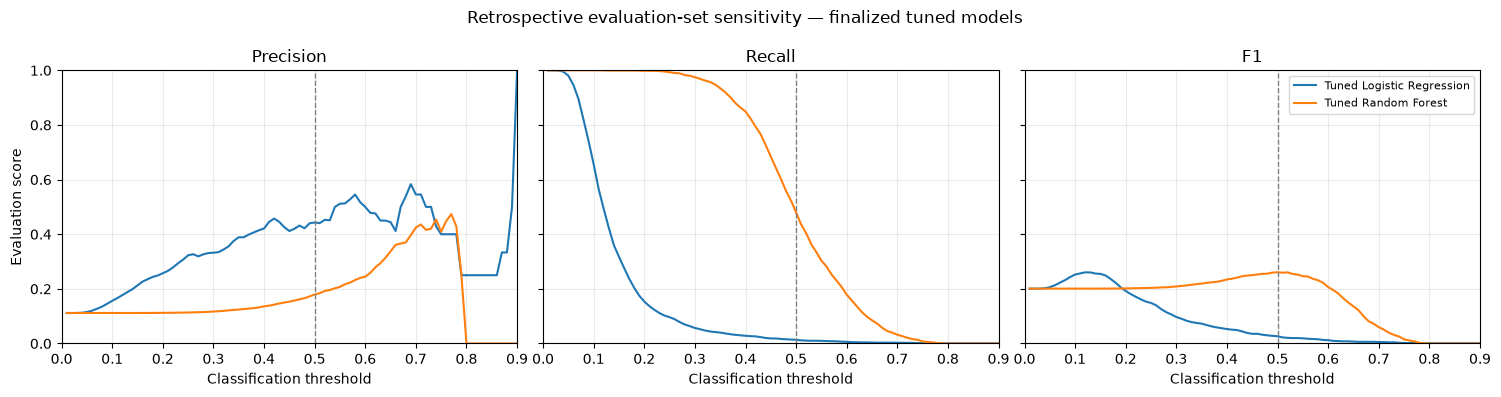

,model,threshold,precision,recall,F1,FP,FN,predicted_positive_count,predicted_positive_percentage
9,Logistic Regression,0.1,0.15640,0.65581,0.25256,8037,782,9527,46.80882
29,Logistic Regression,0.3,0.33247,0.05678,0.09699,259,2143,388,1.90635
39,Logistic Regression,0.4,0.42105,0.02817,0.05281,88,2208,152,0.74682
49,Logistic Regression,0.5,0.44286,0.01364,0.02647,39,2241,70,0.34393
59,Logistic Regression,0.6,0.50000,0.00616,0.01217,14,2258,28,0.13757
99,Random Forest,0.1,0.11166,1.00000,0.20089,18075,0,20347,99.97052
119,Random Forest,0.3,0.11699,0.97447,0.20891,16710,58,18924,92.97892
129,Random Forest,0.4,0.13604,0.84947,0.23452,12257,342,14187,69.70471
139,Random Forest,0.5,0.17913,0.47975,0.26086,4995,1182,6085,29.89731
149,Random Forest,0.6,0.24473,0.17870,0.20656,1253,1866,1659,8.15113


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, metric in zip(axes, ["precision", "recall", "F1"]):
    for name in threshold_model_names:
        curve = threshold_results.loc[threshold_results["model"].eq(name)]
        ax.plot(curve["threshold"], curve[metric], label="Tuned " + name)
    ax.axvline(0.50, color="gray", linestyle="--", linewidth=1)
    ax.set(title=metric.capitalize(), xlabel="Classification threshold", ylim=(0, 1), xlim=(0, 0.90))
    ax.grid(alpha=0.25)
axes[0].set_ylabel("Evaluation score")
axes[-1].legend(fontsize=8)
fig.suptitle("Retrospective evaluation-set sensitivity — finalized tuned models")
fig.tight_layout()
plt.show()

threshold_report_columns = ["model", "threshold", "precision", "recall", "F1", "FP", "FN",
                            "predicted_positive_count", "predicted_positive_percentage"]
# Include 0.10 to illustrate the extra workload and recall from a lower threshold.
representative_threshold_results = threshold_results.loc[
    threshold_results["threshold"].isin([0.10, 0.30, 0.40, 0.50, 0.60]), threshold_report_columns
].copy()
with pd.option_context("display.max_columns", None):
    display(representative_threshold_results.round(5))

## 34. Observed grid maximum F1 and recall-target descriptions

Each model is described separately. Exact maximum-F1 ties retain **all** tied thresholds. Target recall summaries report the highest evaluated threshold meeting the target (the smallest flagged workload on this grid that still meets it); no interpolation or new probability predictions are used. Neither summary is an unbiased estimate of performance after threshold selection. Choosing from these evaluation results would require separate validation before claiming generalization.

In [3]:
maximum_f1_threshold_results = threshold_results.loc[
    threshold_results["F1"].eq(threshold_results.groupby("model")["F1"].transform("max")),
    threshold_report_columns,
].copy()
recall_target_rows = []
for name in threshold_model_names:
    model_rows = threshold_results.loc[threshold_results["model"].eq(name)]
    for target in [0.60, 0.70, 0.80]:
        eligible = model_rows.loc[model_rows["recall"].ge(target)]
        if eligible.empty:
            recall_target_rows.append({"model": name, "target_recall": target,
                                       "status": "Not achieved on evaluated grid"})
        else:
            observed = eligible.sort_values("threshold").iloc[-1]
            recall_target_rows.append({**observed[threshold_report_columns].to_dict(),
                                      "target_recall": target, "status": "Achieved on grid",
                                      "recall_above_target": observed["recall"] - target})
recall_target_threshold_results = pd.DataFrame(recall_target_rows)
print("Retrospective maximum F1 on the evaluated grid (not a selected threshold):")
with pd.option_context("display.max_columns", None):
    display(maximum_f1_threshold_results.round(5))
    print("Retrospective recall-target descriptions:")
    display(recall_target_threshold_results.round(5))
    print("Unchanged probability-ranking metrics at every threshold:")
    display(threshold_results.groupby("model")[["ROC_AUC", "average_precision"]].first().round(5))

Retrospective maximum F1 on the evaluated grid (not a selected threshold):
Retrospective recall-target descriptions:
Unchanged probability-ranking metrics at every threshold:


,model,threshold,precision,recall,F1,FP,FN,predicted_positive_count,predicted_positive_percentage
11,Logistic Regression,0.12,0.17716,0.49164,0.26046,5188,1155,6305,30.97823
139,Random Forest,0.50,0.17913,0.47975,0.26086,4995,1182,6085,29.89731


,model,threshold,precision,recall,F1,FP,FN,predicted_positive_count,predicted_positive_percentage,target_recall,status,recall_above_target
0,Logistic Regression,0.10,0.15640,0.65581,0.25256,8037,782,9527,46.80882,0.6,Achieved on grid,0.05581
1,Logistic Regression,0.09,0.14546,0.74032,0.24315,9881,590,11563,56.81226,0.7,Achieved on grid,0.04032
2,Logistic Regression,0.08,0.13511,0.81866,0.23193,11907,412,13767,67.64113,0.8,Achieved on grid,0.01866
3,Random Forest,0.47,0.16155,0.60255,0.25479,7105,903,8474,41.63514,0.6,Achieved on grid,0.00255
4,Random Forest,0.44,0.14990,0.72579,0.24847,9352,623,11001,54.05100,0.7,Achieved on grid,0.02579
5,Random Forest,0.41,0.13860,0.82306,0.23725,11622,402,13492,66.28998,0.8,Achieved on grid,0.02306


,ROC_AUC,average_precision
model,,
Logistic Regression,0.6478,0.19863
Random Forest,0.6514,0.19931


## 35. Validation and interpretation

**Probability ranking** measures how continuous scores order outcomes: ROC-AUC summarizes discrimination across operating points, and average precision summarizes the precision–recall ranking. Both remain unchanged because the probability arrays and outcome labels are unchanged; neither is determined by one classification threshold. Ranking does not establish probability calibration.

**Fixed-threshold classification** converts the same scores to positive/negative decisions. Accuracy, precision, sensitivity (recall), specificity, F1, error counts, and flagged workload therefore change with the cutoff. The 0.50 row must exactly reproduce the existing tuned-model confusion counts and classification scores.

**Operational threshold selection** requires an explicit business/clinical objective and cost or capacity trade-off. Higher recall may be prioritized when missing a high-risk readmission is costly; higher precision may be prioritized when intervention resources are limited. False positives create review or intervention workload, while false negatives represent missed readmissions. No monetary or clinical costs are assumed here. F1 assigns a particular balance to precision and recall and does not encode these operational costs or true-negative performance.

All observations are predictive/descriptive, not causal evidence that intervention would prevent readmission. This reused evaluation set supplies retrospective sensitivity descriptions, not unbiased threshold optimization. An operational proposal should be developed through training-only validation with a specified objective and assessed on independent data. No final threshold or winning model is selected, and these results trigger no retraining, retuning, resampling, or predictor changes.

**Observed trade-offs:** Logistic Regression's grid maximum F1 was **0.26046 at 0.12** (precision 17.72%, recall 49.16%, 5,188 FP, 1,155 FN). Random Forest's grid maximum was **0.26086 at 0.50** (precision 17.91%, recall 47.98%, 4,995 FP, 1,182 FN). These are separate retrospective observations, not model or cutoff recommendations.

For the 60%/70%/80% recall targets, Logistic Regression's highest qualifying grid thresholds were **0.10/0.09/0.08**, with achieved recall **65.58%/74.03%/81.87%** and precision **15.64%/14.55%/13.51%**. Random Forest's were **0.47/0.44/0.41**, with recall **60.26%/72.58%/82.31%** and precision **16.16%/14.99%/13.86%**. The grid can overshoot the target; these are not exact target solutions. At the 80% target rows, 13,767 LR encounters (67.64%) and 13,492 RF encounters (66.29%) are flagged, including 11,907 and 11,622 false positives respectively. That workload needs an explicit intervention-capacity assessment.

At 0.30, LR flags 388 encounters with 33.25% precision and 5.68% recall, while RF flags 18,924 with 11.70% precision and 97.45% recall: equal numerical thresholds need not represent comparable operating points. At high thresholds, precision spikes can reflect very few flagged encounters; zero-positive rows use the stated zero-precision convention. ROC-AUC/AP remain **0.64780/0.19863 (LR)** and **0.65140/0.19931 (RF)** throughout.

In [4]:
assert len(threshold_results) == 2 * len(threshold_grid) == 180
assert threshold_results["threshold"].between(0, 1, inclusive="neither").all()
assert threshold_results[["TN", "FP", "FN", "TP"]].sum(axis=1).eq(20_353).all()
assert (threshold_results["TP"] + threshold_results["FN"]).eq(2_272).all()
assert (threshold_results["TN"] + threshold_results["FP"]).eq(18_081).all()
assert threshold_results["predicted_positive_count"].eq(threshold_results["TP"] + threshold_results["FP"]).all()
for name in threshold_model_names:
    np.testing.assert_array_equal(threshold_predictions[name]["probabilities"], threshold_probability_snapshots[name])
    ordered = threshold_results.loc[threshold_results["model"].eq(name)].sort_values("threshold")
    assert (np.diff(ordered["predicted_positive_count"]) <= 0).all(), "Lower thresholds cannot flag fewer encounters."
    assert (np.diff(ordered["recall"]) <= 0).all()
    assert ordered["ROC_AUC"].nunique() == ordered["average_precision"].nunique() == 1
    reference = ordered.loc[ordered["threshold"].eq(0.50)].iloc[0]
    np.testing.assert_array_equal(reference[["TN", "FP", "FN", "TP"]].to_numpy(dtype=int),
                                  threshold_reference_matrices[name].ravel())
    for column, original in [("accuracy", "accuracy"), ("precision", "positive_precision"),
                             ("recall", "positive_recall"), ("F1", "positive_F1")]:
        np.testing.assert_allclose(reference[column], threshold_reference_metrics[name][original], rtol=0, atol=1e-12)
assert state_hash((threshold_predictions, threshold_reference_metrics,
                   threshold_reference_matrices, threshold_y_evaluation,
                   threshold_train_positions, threshold_evaluation_positions,
                   threshold_train_patient_ids, threshold_evaluation_patient_ids,
                   threshold_manifest)) == threshold_state_before
assert len(threshold_train_patient_ids.intersection(threshold_evaluation_patient_ids)) == 0
assert threshold_manifest["reproduction_fit_count"] == 2
assert threshold_manifest["search_fit_count"] == 0
assert threshold_manifest["prediction_calls_per_model"] == 1
for filename, original_hash in threshold_artifact_hashes.items():
    assert hashlib.sha256((threshold_output_dir / filename).read_bytes()).hexdigest() == original_hash
assert json.loads(threshold_manifest_path.read_text()) == threshold_manifest
assert hashlib.sha256(threshold_source_path.read_bytes()).hexdigest() == threshold_manifest["source_data_sha256"]
print("PASS: saved probabilities, metrics, labels, split membership, and source data unchanged.")
print("PASS: 180 rows; thresholds strictly between 0 and 1; 20,353 encounters / 2,272 positives / 18,081 negatives in every matrix.")
print("PASS: lowering thresholds never reduces flagged counts; 0.50 results reproduced; zero patient overlap.")
print("PASS: 44 predictors retained; reproduction used two finalized fits and zero search fits; threshold analysis used zero fits.")

PASS: saved probabilities, metrics, labels, split membership, and source data unchanged.
PASS: 180 rows; thresholds strictly between 0 and 1; 20,353 encounters / 2,272 positives / 18,081 negatives in every matrix.
PASS: lowering thresholds never reduces flagged counts; 0.50 results reproduced; zero patient overlap.
PASS: 44 predictors retained; reproduction used two finalized fits and zero search fits; threshold analysis used zero fits.


## 36. Reproducibility and validation checkpoint

Both finalized configurations reproduced the saved evaluation metrics and exact confusion matrices before probabilities were persisted. The saved threshold outputs include all 90 thresholds per model, precision/recall/F1 curves, representative thresholds, and retrospective grid-maximum F1 and recall-target summaries. All threshold preservation assertions passed.

Supporting files:

- [Reproduction script](../scripts/reproduce_finalized_probabilities.py): reuses the original notebook definitions and deterministic split, with no hyperparameter search.
- [Logistic Regression probabilities](../data/model_output/tuned_logistic_regression_evaluation_probabilities.npz) and [Random Forest probabilities](../data/model_output/tuned_random_forest_evaluation_probabilities.npz): source-row positions, outcomes, and positive-class probabilities only; no patient or encounter identifiers.
- [Reproduction manifest](../data/model_output/reproduction_manifest.json): data and artifact hashes, split hashes, predictor list, finalized parameters, environment versions, and metric checks.

The final quality-control pass changed narrative only: all analytical code and saved numerical outputs remain unchanged. Earlier notebooks and raw/cleaned source data are unchanged. The reproduction script refers to fixed notebook cell positions, which are preserved here; future structural edits must keep those references synchronized. Threshold review uses the persisted files and needs no model fitting. The recorded scikit-learn version for reproduction is 1.9.0; the manifest records the other package versions.

## 37. Phase 6 conclusion

Phase 6 assesses prediction of **30-day readmission at discharge** across **101,763 encounters from 71,515 patients**, using **44 approved predictors**. The **11,357 positive encounters (11.16%)** make accuracy alone misleading: the majority-class reference misses every readmission despite high accuracy. Precision, recall, F1, error counts, ROC-AUC, and average precision reveal different aspects of performance.

Patients are separated between training and evaluation, with **zero overlap**. Preprocessing is learned only from training rows; hyperparameter selection uses patient-grouped training CV with preprocessing refitted inside each fold. Evaluation results are reported separately from CV selection scores.

The class-weighted Logistic Regression and Random Forest baselines show different recall, precision, and false-positive burdens at 0.50. Limited training-only tuning improved both models' reported evaluation ranking metrics: tuned Logistic Regression reached **ROC-AUC 0.64780 / AP 0.19863**, and tuned Random Forest reached **ROC-AUC 0.65140 / AP 0.19931**. These descriptive differences do not establish a final winning model. Improved ranking need not improve classification at one threshold: tuned Logistic Regression's recall at 0.50 fell to **1.36%**.

Retrospective threshold sensitivity shows how retrieving more positives increases flagged workload and false positives. The observed grid-maximum F1 thresholds (**0.12 for Logistic Regression; 0.50 for Random Forest**) are evaluation-set descriptions, not production recommendations. ROC-AUC and AP remain unchanged across cutoffs because the probability rankings are unchanged.

Limitations include one repeatedly reported evaluation partition, a limited search, unvalidated probability calibration, no prospective or external clinical validation, and unassessed subgroup performance. Discharge-time feature availability must be confirmed before use. Coefficients, importances, and predictions describe associations, not causes or demonstrated intervention benefit.

**No final production threshold, clinically validated model, or final winning model is claimed.** Operational selection requires a defined business/clinical objective: the cost of missed readmissions, acceptable false-positive workload, and intervention capacity. Such choices need training-only validation and independent assessment; no monetary or clinical costs are assumed here.